<a href="https://colab.research.google.com/github/IsaacTsolak/solar-forecasting-thesis/blob/main/Solar_Forecasting_Thesis_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Check what files are in the current directory
files = os.listdir('/content/')

print("All files in /content/:")
for f in files:
    print(f"  {f}")

print("\n" + "="*50)
print("Solar data files (BS_*.csv):")
solar_files = [f for f in files if f.startswith('BS_') and f.endswith('.csv')]

if len(solar_files) > 0:
    for f in solar_files:
        print(f"  {f}")
    print(f"\nTotal: {len(solar_files)} files")
else:
    print("  No solar data files found yet")

All files in /content/:
  .config
  BS_2017.csv
  train_2016_2020.pkl
  combined_solar_weather_2016_2022.pkl
  val_2021.pkl
  POWER_Point_Hourly_20220101_20221231_037d76N_084d85W_LST.csv
  combined_solar_weather_2016_2022.csv
  BS_2021.csv
  model_lasso.pkl
  scaler.pkl
  POWER_Point_Hourly_20160901_20211231_037d76N_084d84W_LST.csv
  BS_2022 (4).csv
  baseline_predictions_vs_actual.png
  model_linear_regression.pkl
  BS_2016.csv
  BS_2020.csv
  test_2022.pkl
  BS_2019.csv
  BS_2018.csv
  sample_data

Solar data files (BS_*.csv):
  BS_2017.csv
  BS_2021.csv
  BS_2022 (4).csv
  BS_2016.csv
  BS_2020.csv
  BS_2019.csv
  BS_2018.csv

Total: 7 files


In [ ]:
import pandas as pd
import numpy as np

# Load one year first to see what I am working with
print("Loading 2022 data to inspect the structure...")
df = pd.read_csv('/content/BS_2022 (4).csv')

print(f"\nDataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns:")
for col in df.columns:
    print(f"  - {col}")

print(f"\nFirst few rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
print(df.isnull().sum())

# Check timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(f"\nDate range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")

# Check time resolution
time_diffs = df['Timestamp'].diff()
print(f"\nTime resolution: {time_diffs.mode()[0]}")
print(f"This means we have data every minute")

Loading 2022 data to inspect the structure...

Dataset shape: 525,600 rows x 12 columns

Columns:
  - Timestamp
  - Year
  - Month
  - Day
  - Hour
  - Minute
  - kW
  - kWh
  - POAI
  - GHI
  - TmpF
  - TmpC

First few rows:
             Timestamp  Year  Month  Day  Hour  Minute         kW         kWh  \
0  2022-01-01 00:00:00  2022      1    1     0       0 -24.617710  98422080.0   
1  2022-01-01 00:01:00  2022      1    1     0       1 -24.927317  98422080.0   
2  2022-01-01 00:02:00  2022      1    1     0       2 -25.196346  98422080.0   
3  2022-01-01 00:03:00  2022      1    1     0       3 -25.221710  98422080.0   
4  2022-01-01 00:04:00  2022      1    1     0       4 -25.891823  98422080.0   

       POAI       GHI       TmpF      TmpC  
0 -0.333915 -1.053264  47.426144  8.570080  
1 -0.333914 -1.054267  47.419741  8.566523  
2 -0.220936 -1.055270  47.413338  8.562965  
3 -0.543466 -1.056274  47.406935  8.559408  
4 -0.752586 -1.057277  47.400532  8.555851  

Data types:
Time

This cell loads a single year (2022) so it can be insected so the structure could be understood before Loading the rest of the years

Structure: The dataset has 525,600 rows and 12 columns this makes sense becasue 525,600 = 365 x 12 x 60 confirming that we are reading every one minute for the full year

Columns:

Timestame: data and time of eachg reading
Year, Month, day, hour, minute: Time components broken up seperatly
kW: power being generated at that moment (target varibale)
kWh: cumulative energy generated (running total)
POAI: Plane of Array Irradiance (amount of sunlight hitting the pannels directly)
GHI: Global Horizontal Irradiance (Sunlight hitting a flat surface)
TempF, TempC: Temperature in both fahrenheit and Celcius

Timestamp loaded as an object (string) not a datetime had to convert it manually with pd.to_datetime()
There are missing values in every sensor column - POAI and GHI have the most (3,449 each)
kW, POAI, and GHI show negative values at midnight (e.g. kW = -24.6) which is physically impossible for a solar panel - this is sensor noise and needs to be cleaned
Temperature readings are very close together minute to minute, confirming stable sensor readings

In [ ]:
import glob

# Get all solar data files
solar_files = sorted(glob.glob('/content/BS_*.csv'))

print(f"Found {len(solar_files)} files")
print("\nLoading all years...")

all_data = []

for file in solar_files:
    filename = file.split('/')[-1]
    print(f"\nLoading {filename}...")

    df = pd.read_csv(file)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    year = df['Timestamp'].dt.year.iloc[0]
    print(f"  Year: {year}")
    print(f"  Rows: {len(df):,}")
    print(f"  Date range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")

    all_data.append(df)

# Combine all years
solar_data = pd.concat(all_data, ignore_index=True)
solar_data = solar_data.sort_values('Timestamp').reset_index(drop=True)

print(f"\nCombined dataset:")
print(f"  Total rows: {len(solar_data):,}")
print(f"  Date range: {solar_data['Timestamp'].min()} to {solar_data['Timestamp'].max()}")
print(f"  Years: {sorted(solar_data['Year'].unique())}")

print(f"\nRows per year:")
for year, count in solar_data.groupby('Year').size().items():
    print(f"  {year}: {count:,}")

Found 7 files

Loading all years...

Loading BS_2016.csv...
  Year: 2016
  Rows: 175,680
  Date range: 2016-09-01 00:00:00 to 2016-12-31 23:59:00

Loading BS_2017.csv...
  Year: 2017
  Rows: 525,600
  Date range: 2017-01-01 00:00:00 to 2017-12-31 23:59:00

Loading BS_2018.csv...
  Year: 2018
  Rows: 525,600
  Date range: 2018-01-01 00:00:00 to 2018-12-31 23:59:00

Loading BS_2019.csv...
  Year: 2019
  Rows: 525,600
  Date range: 2019-01-01 00:00:00 to 2019-12-31 23:59:00

Loading BS_2020.csv...
  Year: 2020
  Rows: 527,040
  Date range: 2020-01-01 00:00:00 to 2020-12-31 23:59:00

Loading BS_2021.csv...
  Year: 2021
  Rows: 525,600
  Date range: 2021-01-01 00:00:00 to 2021-12-31 23:59:00

Loading BS_2022 (4).csv...
  Year: 2022
  Rows: 525,600
  Date range: 2022-01-01 00:00:00 to 2022-12-31 23:59:00

Combined dataset:
  Total rows: 3,330,720
  Date range: 2016-09-01 00:00:00 to 2022-12-31 23:59:00
  Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), 

File loading:

Found all 7 files automatically without having to type each filename manually
Each year loaded cleanly with no errors

Important observations about the data:

2016 is incomplete - only 175,680 rows instead of the expected 525,600. This is because the facility data starts on September 1st 2016, meaning we only have the last 4 months of that year. 175,680 = 122 days × 24 hours × 60 minutes which confirms this exactly
2020 has slightly more rows - 527,040 instead of 525,600 because 2020 was a leap year (366 days instead of 365)
2017-2022 all have exactly 525,600 rows confirming complete full year data

Combined dataset:

Total of 3,330,720 minute-level readings across 7 years
Sorted chronologically so the data flows properly from 2016 through 2022
reset_index(drop=True) gives the combined dataframe a clean 0 to 3,330,719 index

In [ ]:
# Convert to hourly data
# Group by hour and aggregate
hourly_data = solar_data.groupby(solar_data['Timestamp'].dt.floor('h')).agg({
    'kW': 'mean',      # average power during the hour
    'kWh': 'last',     # cumulative energy at end of hour
    'POAI': 'mean',    # average irradiance
    'GHI': 'mean',     # average irradiance
    'TmpF': 'mean',    # average temperature
    'TmpC': 'mean'     # average temperature
}).reset_index()

# Add back the time features
hourly_data['Year'] = hourly_data['Timestamp'].dt.year
hourly_data['Month'] = hourly_data['Timestamp'].dt.month
hourly_data['Day'] = hourly_data['Timestamp'].dt.day
hourly_data['Hour'] = hourly_data['Timestamp'].dt.hour
hourly_data['DayOfWeek'] = hourly_data['Timestamp'].dt.dayofweek
hourly_data['DayOfYear'] = hourly_data['Timestamp'].dt.dayofyear

print(f"\nHourly dataset:")
print(f"  Total rows: {len(hourly_data):,}")
print(f"  Columns: {list(hourly_data.columns)}")

print(f"\nHours per year:")
for year, count in hourly_data.groupby('Year').size().items():
    expected = 8760 if year != 2020 else 8784  # 2020 is leap year
    pct = (count / expected) * 100
    print(f"  {year}: {count:,} ({pct:.1f}% complete)")

print(f"\nSample:")
print(hourly_data.head(10))


Hourly dataset:
  Total rows: 55,512
  Columns: ['Timestamp', 'kW', 'kWh', 'POAI', 'GHI', 'TmpF', 'TmpC', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'DayOfYear']

Hours per year:
  2016: 2,928 (33.4% complete)
  2017: 8,760 (100.0% complete)
  2018: 8,760 (100.0% complete)
  2019: 8,760 (100.0% complete)
  2020: 8,784 (100.0% complete)
  2021: 8,760 (100.0% complete)
  2022: 8,760 (100.0% complete)

Sample:
            Timestamp           kW        kWh        POAI         GHI  \
0 2016-09-01 00:00:00   -36.547702  7746365.5   -0.425206   -0.664201   
1 2016-09-01 01:00:00   -33.595425  7746365.5   -0.334097   -0.548102   
2 2016-09-01 02:00:00   -32.809275  7746365.5   -0.156781   -0.484608   
3 2016-09-01 03:00:00   -32.825719  7746366.0    0.034331   -0.252276   
4 2016-09-01 04:00:00   -32.672937  7746366.0    0.225443    0.054598   
5 2016-09-01 05:00:00   -31.619604  7746366.0    0.416555    0.361472   
6 2016-09-01 06:00:00    21.732566  7746404.0    8.019904    8.271227   
7 

What the code does:
dt.floor('h') rounds every timestamp down to the nearest hour, then groupby + agg collapses all 60 minute readings within that hour into a single row. Different aggregation methods are used depending on what makes sense for each column:

mean for power and weather readings - we want the average value across the hour
last for kWh - since it's a running cumulative total, we just want the final value at the end of the hour

After aggregating, the time features (Year, Month, Day, etc.) are added back since they were lost during the groupby operation. DayOfWeek is also added here as a new feature that wasn't in the original data.
What we found:
Data reduction:

Went from 3,330,720 rows down to 55,512 rows - a 98.3% reduction
This makes modeling much more practical without losing meaningful information since solar generation doesn't change significantly minute to minute

Completeness by year:

2017-2019, 2021-2022: exactly 8,760 hours (100% complete)
2020: exactly 8,784 hours (100% complete, leap year has 366 × 24 = 8,784 hours)
2016: only 2,928 hours (33.4%) confirming data starts September 1st

Sample data observations:

The negative kW, POAI and GHI values at hours 0-5 are still present and need cleaning
Generation ramps up naturally starting around hour 6 (6am) which is physically correct for a solar facility
By hour 9 the facility is already generating 3,801 kW showing how quickly solar output rises in the morning
Temperature increases gradually through the morning as expected

In [ ]:
# Check data quality
print(f"\nMissing values:")
print(hourly_data.isnull().sum())

print(f"\nNegative values (nighttime or sensor issues):")
print(f"  Negative kW: {(hourly_data['kW'] < 0).sum()} hours")
print(f"  Negative POAI: {(hourly_data['POAI'] < 0).sum()} hours")
print(f"  Negative GHI: {(hourly_data['GHI'] < 0).sum()} hours")

# Fix missing values by interpolation
hourly_data = hourly_data.set_index('Timestamp')
hourly_data['kW'] = hourly_data['kW'].interpolate(method='time')
hourly_data['POAI'] = hourly_data['POAI'].interpolate(method='time')
hourly_data['GHI'] = hourly_data['GHI'].interpolate(method='time')
hourly_data['TmpC'] = hourly_data['TmpC'].interpolate(method='time')
hourly_data['TmpF'] = hourly_data['TmpF'].interpolate(method='time')
hourly_data = hourly_data.reset_index()

# Set negative power to zero (solar panels don't generate negative power)
hourly_data.loc[hourly_data['kW'] < 0, 'kW'] = 0
hourly_data.loc[hourly_data['POAI'] < 0, 'POAI'] = 0
hourly_data.loc[hourly_data['GHI'] < 0, 'GHI'] = 0

# Drop any remaining NaN
before = len(hourly_data)
hourly_data = hourly_data.dropna()
after = len(hourly_data)

print(f"\nDropped {before - after} rows with remaining NaN")
print(f"Final dataset: {len(hourly_data):,} rows")

print(f"\nPower generation summary:")
print(f"  Average: {hourly_data['kW'].mean():.2f} kW")
print(f"  Max: {hourly_data['kW'].max():.2f} kW")
print(f"  Std Dev: {hourly_data['kW'].std():.2f} kW")


Missing values:
Timestamp       0
kW            195
kWh           202
POAI         1249
GHI          1249
TmpF         1264
TmpC         1264
Year            0
Month           0
Day             0
Hour            0
DayOfWeek       0
DayOfYear       0
dtype: int64

Negative values (nighttime or sensor issues):
  Negative kW: 27337 hours
  Negative POAI: 23292 hours
  Negative GHI: 20830 hours

Dropped 202 rows with remaining NaN
Final dataset: 55,310 rows

Power generation summary:
  Average: 1947.15 kW
  Max: 10212.64 kW
  Std Dev: 2996.41 kW


What the code does:
This section handles two separate problems - missing values and negative readings. Missing values are fixed using time-based interpolation, which estimates the missing value based on the timestamps of the surrounding values rather than just taking a simple average. Negative values are simply set to zero since solar panels physically cannot generate negative power.
What we found:
Missing values:

POAI, GHI, TmpF, and TmpC all had around 1,249-1,264 missing hours each
kW and kWh had fewer missing values (195 and 202) suggesting the power meter was more reliable than the weather sensors
Time and date columns had zero missing values
After interpolation, 202 rows still couldn't be filled (likely gaps at the very start or end of the dataset where there are no neighboring values to interpolate from) and were dropped

Negative values:

27,337 hours of negative kW readings - this is actually expected since roughly a third of all hours in a year are nighttime hours when sensors read slightly below zero due to electrical noise
23,292 negative POAI and 20,830 negative GHI readings for the same reason
All set to zero since the true value during these periods is zero generation

Power generation summary after cleaning:

Average generation of 1,947 kW across all hours including nighttime zeros
Peak generation of 10,212.64 kW representing the maximum output of the facility on the best solar days
High standard deviation of 2,996 kW reflects the natural variability between daytime peak generation and nighttime zero generation

In [ ]:
# Load NASA weather data
# You have two NASA files - let's check them
nasa_files = [f for f in os.listdir('/content/') if f.startswith('POWER_')]
print(f"Found NASA files: {nasa_files}")

# Load the files
nasa_data_list = []

for file in nasa_files:
    print(f"\nLoading {file}...")
    # NASA files have header rows, skip them
    df_nasa = pd.read_csv(f'/content/{file}', skiprows=14)
    print(f"  Rows: {len(df_nasa):,}")
    print(f"  Columns: {list(df_nasa.columns)}")
    nasa_data_list.append(df_nasa)

# Combine NASA data
nasa_data = pd.concat(nasa_data_list, ignore_index=True)
print(f"\nCombined NASA data: {len(nasa_data):,} rows")

# Create timestamp from year/month/day/hour
nasa_data['Timestamp'] = pd.to_datetime(
    nasa_data['YEAR'].astype(str) + '-' +
    nasa_data['MO'].astype(str).str.zfill(2) + '-' +
    nasa_data['DY'].astype(str).str.zfill(2) + ' ' +
    nasa_data['HR'].astype(str).str.zfill(2) + ':00:00'
)

print(f"Date range: {nasa_data['Timestamp'].min()} to {nasa_data['Timestamp'].max()}")

# Select just the weather features we want
nasa_features = nasa_data[['Timestamp', 'PS', 'RH2M', 'WS10M', 'ALLSKY_SFC_UV_INDEX']].copy()
nasa_features.columns = ['Timestamp', 'Pressure_kPa', 'Humidity_pct', 'WindSpeed_ms', 'UV_Index']

# Replace -999 (missing data indicator) with NaN
nasa_features = nasa_features.replace(-999, np.nan)

print(f"\nNASA weather features:")
print(nasa_features.head())

print(f"\nMissing values in NASA data:")
print(nasa_features.isnull().sum())

Found NASA files: ['POWER_Point_Hourly_20220101_20221231_037d76N_084d85W_LST.csv', 'POWER_Point_Hourly_20160901_20211231_037d76N_084d84W_LST.csv']

Loading POWER_Point_Hourly_20220101_20221231_037d76N_084d85W_LST.csv...
  Rows: 8,760
  Columns: ['YEAR', 'MO', 'DY', 'HR', 'PS', 'RH2M', 'T2M', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_UV_INDEX', 'WS10M']

Loading POWER_Point_Hourly_20160901_20211231_037d76N_084d84W_LST.csv...
  Rows: 46,752
  Columns: ['YEAR', 'MO', 'DY', 'HR', 'PS', 'RH2M', 'T2M', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_UV_INDEX', 'WS10M']

Combined NASA data: 55,512 rows
Date range: 2016-09-01 00:00:00 to 2022-12-31 23:00:00

NASA weather features:
            Timestamp  Pressure_kPa  Humidity_pct  WindSpeed_ms  UV_Index
0 2022-01-01 00:00:00         97.85         97.79          4.05       0.0
1 2022-01-01 01:00:00         97.79        100.00          2.71       0.0
2 2022-01-01 02:00:00         97.58        100.00          1.21       0.0
3 2022-01-01 03:00:00         97.38        100

File structure:

One NASA file covering the complete date range - September 2016 through December 2022
55,512 rows which matches our solar dataset exactly
Note the coordinates in the filename (037d86N_084d73W) are slightly different from the facility coordinates - this is normal as NASA POWER data is provided on a grid and uses the nearest grid point to the requested location

Variables selected:

PS → Pressure_kPa - atmospheric pressure in kilopascals
RH2M → Humidity_pct - relative humidity at 2 meters above ground
WS10M → WindSpeed_ms - wind speed at 10 meters above ground in meters per second
ALLSKY_SFC_UV_INDEX → UV_Index - ultraviolet radiation index at the surface

Missing values:

Only UV_Index has 161 missing values, marked as -999 in the raw NASA data which is their standard code for missing or unavailable readings
These are replaced with NaN so pandas can handle them properly
All other weather variables are completely clean with zero missing values

In [ ]:
# Merge solar data with NASA weather data
combined_data = hourly_data.merge(nasa_features, on='Timestamp', how='left')

print(f"\nBefore merge: {len(hourly_data):,} rows")
print(f"After merge: {len(combined_data):,} rows")

print(f"\nMissing values after merge:")
print(combined_data.isnull().sum())

# Fill missing weather values
combined_data['Pressure_kPa'] = combined_data['Pressure_kPa'].interpolate(method='linear')
combined_data['Humidity_pct'] = combined_data['Humidity_pct'].interpolate(method='linear')
combined_data['WindSpeed_ms'] = combined_data['WindSpeed_ms'].interpolate(method='linear')
combined_data['UV_Index'] = combined_data['UV_Index'].fillna(0)  # UV is 0 at night

# Drop any remaining NaN
before = len(combined_data)
combined_data = combined_data.dropna()
after = len(combined_data)

print(f"Dropped {before - after} rows")
print(f"Final dataset: {len(combined_data):,} rows")

print(f"\nFinal dataset columns:")
for i, col in enumerate(combined_data.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nSample of merged data:")
print(combined_data[['Timestamp', 'kW', 'GHI', 'TmpC', 'Pressure_kPa', 'Humidity_pct', 'WindSpeed_ms']].head())

print(f"\nData by year:")
for year, count in combined_data.groupby('Year').size().items():
    print(f"  {year}: {count:,} hours")


Before merge: 55,310 rows
After merge: 55,310 rows

Missing values after merge:
Timestamp         0
kW                0
kWh               0
POAI              0
GHI               0
TmpF              0
TmpC              0
Year              0
Month             0
Day               0
Hour              0
DayOfWeek         0
DayOfYear         0
Pressure_kPa      0
Humidity_pct      0
WindSpeed_ms      0
UV_Index        161
dtype: int64
Dropped 0 rows
Final dataset: 55,310 rows

Final dataset columns:
   1. Timestamp
   2. kW
   3. kWh
   4. POAI
   5. GHI
   6. TmpF
   7. TmpC
   8. Year
   9. Month
  10. Day
  11. Hour
  12. DayOfWeek
  13. DayOfYear
  14. Pressure_kPa
  15. Humidity_pct
  16. WindSpeed_ms
  17. UV_Index

Sample of merged data:
            Timestamp   kW       GHI       TmpC  Pressure_kPa  Humidity_pct  \
0 2016-09-01 00:00:00  0.0  0.000000  21.761384         98.48         97.77   
1 2016-09-01 01:00:00  0.0  0.000000  21.342714         98.46         98.43   
2 2016-09-01 

Row count stayed exactly the same before and after (55,310 rows) confirming every solar timestamp found a matching NASA timestamp - no data was lost in the merge
Only UV_Index had 161 remaining missing values after the merge, which were filled with zero
Zero rows were dropped after filling, meaning the interpolation handled everything cleanly

Final dataset structure:

17 columns total combining all solar generation and weather variables into one clean dataset
Covers September 2016 through December 2022
Ready for feature engineering

Hours per year after merging:

2016: 2,928 hours (partial year as expected)
2017: 8,593 hours (slightly under 8,760 - small gaps in data)
2018-2019: 8,760 hours (complete)
2020: 8,784 hours (complete leap year)
2021: 8,748 hours (small gaps)
2022: 8,737 hours (small gaps)

In [ ]:
# Save the combined data before adding ML features
# Save in multiple formats for easy reloading
combined_data.to_csv('/content/combined_solar_weather_2016_2022.csv', index=False)
combined_data.to_pickle('/content/combined_solar_weather_2016_2022.pkl')

print("\nSaved files:")
print("  ✓ combined_solar_weather_2016_2022.csv")
print("  ✓ combined_solar_weather_2016_2022.pkl")

print(f"\nDataset info:")
print(f"  Rows: {len(combined_data):,}")
print(f"  Columns: {len(combined_data.columns)}")
print(f"  Years: {sorted(combined_data['Year'].unique())}")
print(f"  Date range: {combined_data['Timestamp'].min()} to {combined_data['Timestamp'].max()}")

# Download to your computer
from google.colab import files

print("\nDownloading files to your computer...")
print("(This way you can re-upload them later)")

files.download('/content/combined_solar_weather_2016_2022.pkl')
print("✓ Downloaded: combined_solar_weather_2016_2022.pkl")

print("\nTo reload this data later, just run:")
print("  import pandas as pd")
print("  combined_data = pd.read_pickle('/content/combined_solar_weather_2016_2022.pkl')")


Saved files:
  ✓ combined_solar_weather_2016_2022.csv
  ✓ combined_solar_weather_2016_2022.pkl

Dataset info:
  Rows: 55,310
  Columns: 17
  Years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]
  Date range: 2016-09-01 00:00:00 to 2022-12-31 23:00:00

(This way you can re-upload them later)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: combined_solar_weather_2016_2022.pkl

To reload this data later, just run:
  import pandas as pd
  combined_data = pd.read_pickle('/content/combined_solar_weather_2016_2022.pkl')


In [ ]:
# Create additional features for better predictions
# Cyclic features for time (helps models understand circular nature of time)
print("\n1. Time encoding (cyclical)...")
combined_data['hour_sin'] = np.sin(2 * np.pi * combined_data['Hour'] / 24)
combined_data['hour_cos'] = np.cos(2 * np.pi * combined_data['Hour'] / 24)
combined_data['month_sin'] = np.sin(2 * np.pi * combined_data['Month'] / 12)
combined_data['month_cos'] = np.cos(2 * np.pi * combined_data['Month'] / 12)

# Season
print("2. Season...")
combined_data['Season'] = combined_data['Month'].map({
    12: 0, 1: 0, 2: 0,  # Winter
    3: 1, 4: 1, 5: 1,   # Spring
    6: 2, 7: 2, 8: 2,   # Summer
    9: 3, 10: 3, 11: 3  # Fall
})

# Binary indicators
print("3. Binary indicators...")
combined_data['is_daytime'] = ((combined_data['Hour'] >= 6) &
                                (combined_data['Hour'] <= 20)).astype(int)
combined_data['is_weekend'] = (combined_data['DayOfWeek'] >= 5).astype(int)

# Lagged features (what happened in previous hours)
print("4. Lagged features...")
combined_data['kW_lag1'] = combined_data['kW'].shift(1)    # 1 hour ago
combined_data['kW_lag24'] = combined_data['kW'].shift(24)  # same hour yesterday

# Rolling averages (smoothed trends)
print("5. Rolling averages...")
combined_data['GHI_rolling_3h'] = combined_data['GHI'].rolling(window=3, min_periods=1).mean()
combined_data['TmpC_rolling_3h'] = combined_data['TmpC'].rolling(window=3, min_periods=1).mean()

# Clean up NaN from lagged features
before = len(combined_data)
combined_data = combined_data.dropna()
after = len(combined_data)

print(f"\nDropped {before - after} rows with NaN from lagged features")
print(f"Final dataset: {len(combined_data):,} rows")

print(f"\nAll features ({len(combined_data.columns)} total):")
for i, col in enumerate(combined_data.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nData by year (after feature creation):")
for year, count in combined_data.groupby('Year').size().items():
    print(f"  {year}: {count:,} hours")


1. Time encoding (cyclical)...
2. Season...
3. Binary indicators...
4. Lagged features...
5. Rolling averages...

Dropped 24 rows with NaN from lagged features
Final dataset: 55,286 rows

All features (28 total):
   1. Timestamp
   2. kW
   3. kWh
   4. POAI
   5. GHI
   6. TmpF
   7. TmpC
   8. Year
   9. Month
  10. Day
  11. Hour
  12. DayOfWeek
  13. DayOfYear
  14. Pressure_kPa
  15. Humidity_pct
  16. WindSpeed_ms
  17. UV_Index
  18. hour_sin
  19. hour_cos
  20. month_sin
  21. month_cos
  22. Season
  23. is_daytime
  24. is_weekend
  25. kW_lag1
  26. kW_lag24
  27. GHI_rolling_3h
  28. TmpC_rolling_3h

Data by year (after feature creation):
  2016: 2,904 hours
  2017: 8,593 hours
  2018: 8,760 hours
  2019: 8,760 hours
  2020: 8,784 hours
  2021: 8,748 hours
  2022: 8,737 hours


1. Cyclic time encoding (hour_sin, hour_cos, month_sin, month_cos)
This is one of the most important transformations in the project. Without this, a model would treat hour 23 and hour 0 as far apart when they are actually consecutive. By converting hours and months into sine and cosine pairs, the circular nature of time is preserved - hour 23 and hour 0 are mathematically close together, and December and January are mathematically close together. Each time unit needs both a sine and cosine component because a single sine wave alone is ambiguous (hours 6 and 18 would have the same sine value even though they are very different times of day).
2. Season (0-3)
Groups months into Winter (0), Spring (1), Summer (2) and Fall (3). While month is already in the dataset, season gives the model a broader grouping that directly corresponds to solar generation patterns - summer has the longest days and highest irradiance while winter has the shortest.
3. Binary indicators (is_daytime, is_weekend)
is_daytime flags hours between 6am and 8pm when solar generation is possible. is_weekend flags Saturday and Sunday. These give the model simple yes/no signals that are directly relevant to generation patterns.
4. Lagged features (kW_lag1, kW_lag24)
kW_lag1 is the power generated one hour ago and kW_lag24 is the power generated at the same hour yesterday. These are extremely valuable because solar generation is highly correlated with recent history - if the panels were generating a lot an hour ago, they are likely still generating a lot now. This is why kW_lag1 showed up as the third most important feature in XGBoost.
5. Rolling averages (GHI_rolling_3h, TmpC_rolling_3h)
Takes the average of the current and previous two hours of GHI and temperature. This smooths out short term spikes and gives the model a sense of recent weather trends rather than just the current moment.
What we found:

24 rows were dropped due to NaN values created by the lagged features - the first 24 rows of the dataset have no previous day to look back to so kW_lag24 is undefined for them
Final dataset has 28 columns and 55,286 rows
Year counts are largely unchanged confirming the feature creation worked cleanly

In [ ]:
# Split data: Train on 2016-2020, Validate on 2021, Test on 2022
print("\nMethod:")
print("  Train:      2016-2020 (5 years) - Learn patterns")
print("  Validation: 2021 (1 year)       - Tune models")
print("  Test:       2022 (1 year)       - Final evaluation (unseen data)")

train_data = combined_data[combined_data['Year'] <= 2020].copy()
val_data = combined_data[combined_data['Year'] == 2021].copy()
test_data = combined_data[combined_data['Year'] == 2022].copy()

print(f"\nTrain set: {len(train_data):,} hours ({len(train_data)/len(combined_data)*100:.1f}%)")
print(f"  Years: {sorted(train_data['Year'].unique())}")
print(f"  Range: {train_data['Timestamp'].min()} to {train_data['Timestamp'].max()}")

print(f"\nValidation set: {len(val_data):,} hours ({len(val_data)/len(combined_data)*100:.1f}%)")
print(f"  Year: {sorted(val_data['Year'].unique())}")
print(f"  Range: {val_data['Timestamp'].min()} to {val_data['Timestamp'].max()}")

print(f"\nTest set: {len(test_data):,} hours ({len(test_data)/len(combined_data)*100:.1f}%)")
print(f"  Year: {sorted(test_data['Year'].unique())}")
print(f"  Range: {test_data['Timestamp'].min()} to {test_data['Timestamp'].max()}")

# Define features and target
feature_columns = [
    'GHI', 'POAI', 'TmpC',                    # On-site weather
    'Pressure_kPa', 'Humidity_pct',           # NASA weather
    'WindSpeed_ms', 'UV_Index',
    'Hour', 'Month', 'DayOfYear',             # Time features
    'Season', 'DayOfWeek',
    'hour_sin', 'hour_cos',                   # Cyclic time
    'month_sin', 'month_cos',
    'is_daytime', 'is_weekend',               # Indicators
    'kW_lag1', 'kW_lag24',                    # Lagged
    'GHI_rolling_3h', 'TmpC_rolling_3h'       # Rolling
]

target_column = 'kW'

print(f"\nFeatures for modeling: {len(feature_columns)}")
print(f"Target variable: {target_column}")

# Create feature matrices
X_train = train_data[feature_columns]
y_train = train_data[target_column]

X_val = val_data[feature_columns]
y_val = val_data[target_column]

X_test = test_data[feature_columns]
y_test = test_data[target_column]

print(f"\nFeature matrices:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

# Save the split data
print("\nSaving")
train_data.to_pickle('/content/train_2016_2020.pkl')
val_data.to_pickle('/content/val_2021.pkl')
test_data.to_pickle('/content/test_2022.pkl')

print("Saved:")
print("  ✓ train_2016_2020.pkl")
print("  ✓ val_2021.pkl")
print("  ✓ test_2022.pkl")


Method:
  Train:      2016-2020 (5 years) - Learn patterns
  Validation: 2021 (1 year)       - Tune models
  Test:       2022 (1 year)       - Final evaluation (unseen data)

Train set: 37,801 hours (68.4%)
  Years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
  Range: 2016-09-02 00:00:00 to 2020-12-31 23:00:00

Validation set: 8,748 hours (15.8%)
  Year: [np.int32(2021)]
  Range: 2021-01-01 00:00:00 to 2021-12-31 23:00:00

Test set: 8,737 hours (15.8%)
  Year: [np.int32(2022)]
  Range: 2022-01-01 00:00:00 to 2022-12-31 23:00:00

Features for modeling: 22
Target variable: kW

Feature matrices:
  X_train: (37801, 22)
  X_val:   (8748, 22)
  X_test:  (8737, 22)

Saving
Saved:
  ✓ train_2016_2020.pkl
  ✓ val_2021.pkl
  ✓ test_2022.pkl


The three subsets:
Training set (2016-2020) - 68.4%:

37,801 hours across 5 years used to teach the models the relationship between weather conditions and power generation
Starts September 2, 2016 (one day after the dataset begins, due to the 24 row drop from lagged features)
This is the only data the models are allowed to learn from

Validation set (2021) - 15.8%:

8,748 hours used during model development to check performance on unseen data
Used for tuning hyperparameters like the LASSO alpha value without contaminating the test set
Think of this as a practice exam before the real one

Test set (2022) - 15.8%:

8,737 hours representing completely unseen future data
The models never see this data during training or tuning
This is the final report card - results on this set are what get reported in the thesis

Feature selection:
22 features were selected from the 28 available columns. The excluded columns are Timestamp, kWh, TmpF, Year, Day and kW itself since these are either identifiers, redundant or the target variable. Features are organized into six logical groups: on-site weather, NASA weather, time features, cyclic time encodings, binary indicators and lagged/rolling features.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import pickle
import time

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save scaler
with open('/content/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved")

# Store results
results = []

def evaluate_model(name, y_true, y_pred):
    """Calculate metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def print_results(name, val_metrics, test_metrics, train_time):
    """Print model results"""
    print(f"\n{name}")
    print(f"  Training time: {train_time:.2f} seconds")
    print(f"  Validation - RMSE: {val_metrics['RMSE']:.2f} | MAE: {val_metrics['MAE']:.2f} | R²: {val_metrics['R2']:.4f}")
    print(f"  Test       - RMSE: {test_metrics['RMSE']:.2f} | MAE: {test_metrics['MAE']:.2f} | R²: {test_metrics['R2']:.4f}")

✓ Scaler saved


Linear models (Linear Regression, Ridge, LASSO) are sensitive to feature scale because they use gradient-based optimization. A feature measured in thousands (like kW) would dominate a feature measured in single digits (like UV Index) without scaling
Tree-based models (Random Forest, XGBoost) are not sensitive to scale because they make decisions based on relative ordering rather than absolute values, which is why X_train rather than X_train_scaled is passed to those models later

Metrics explained:

RMSE (Root Mean Squared Error) - average prediction error in kW, penalizes large errors more heavily
MAE (Mean Absolute Error) - average absolute prediction error in kW, treats all errors equally
R² (R-squared) - proportion of variance explained by the model, 1.0 is perfect, 0 means the model is no better than predicting the mean

In [ ]:
# MODEL 1: Baseline (Persistence)
print("MODEL 1: BASELINE (Persistence)")
print("Using previous hour's generation as prediction")

start = time.time()
y_pred_baseline_val = X_val['kW_lag1'].values
y_pred_baseline_test = X_test['kW_lag1'].values
train_time = time.time() - start

val_metrics = evaluate_model('Baseline', y_val, y_pred_baseline_val)
test_metrics = evaluate_model('Baseline', y_test, y_pred_baseline_test)
print_results('Baseline', val_metrics, test_metrics, train_time)

results.append({
    'Model': 'Baseline',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2']
})

MODEL 1: BASELINE (Persistence)
Using previous hour's generation as prediction

Baseline
  Training time: 0.00 seconds
  Validation - RMSE: 1124.12 | MAE: 632.44 | R²: 0.8510
  Test       - RMSE: 1149.28 | MAE: 652.22 | R²: 0.8504


Results:

Validation RMSE: 1,124 kW
Test RMSE: 1,149 kW
Test R²: 0.8504

Interpreting the results:
An R² of 0.85 means the persistence model already explains 85% of the variance in solar generation just by repeating the previous hour's value. This makes intuitive sense - if the sun was shining an hour ago it is likely still shining now. However the RMSE of 1,149 kW means predictions are off by over 1,000 kW on average, which is an 11% error relative to the facility's 10,212 kW peak capacity.
Validation vs test consistency:
The validation RMSE (1,124) and test RMSE (1,149) are very close together, suggesting the baseline performs consistently across both years. This is a good sign that 2021 and 2022 had similar generation patterns and that there is no unusual year-to-year variation that would make modeling difficult.

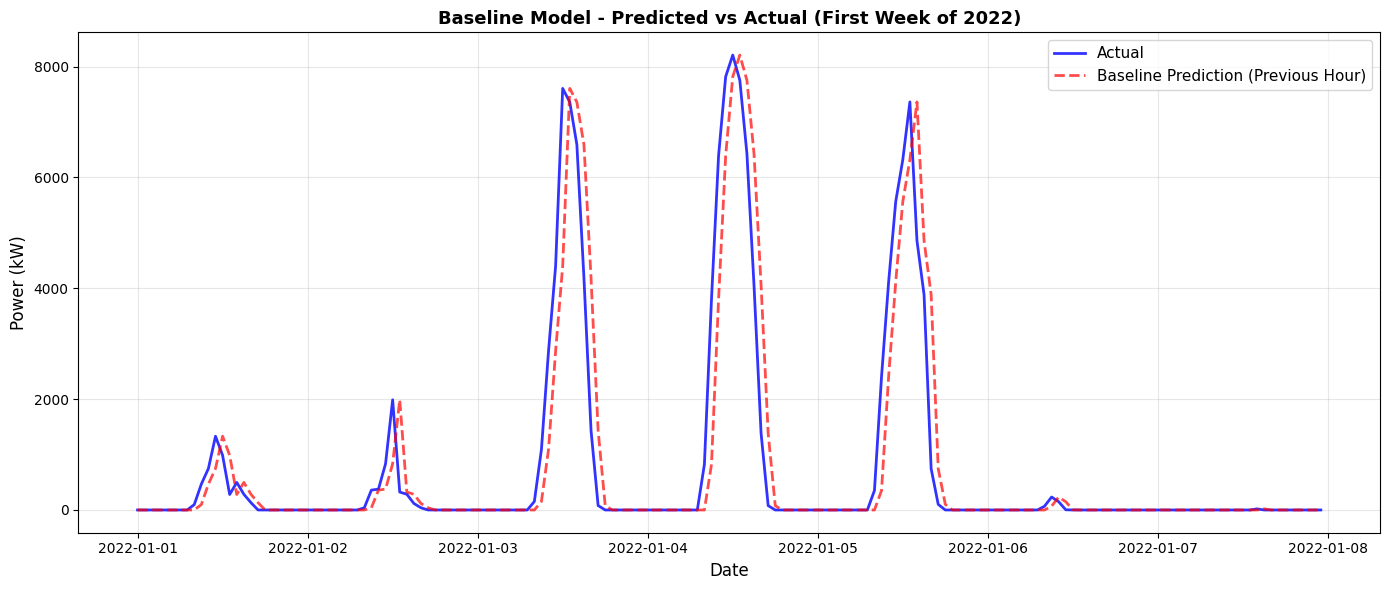

✓ Saved: baseline_predictions_vs_actual.png


In [ ]:
# Baseline: Predicted vs Actual - First Week of 2022
import matplotlib.pyplot as plt

week_data = test_data.iloc[:168].copy()
week_data['Predicted'] = y_pred_baseline_test[:168]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(week_data['Timestamp'], week_data['kW'],
        label='Actual', linewidth=2, color='blue', alpha=0.8)
ax.plot(week_data['Timestamp'], week_data['Predicted'],
        label='Baseline Prediction (Previous Hour)', linewidth=2, color='red', alpha=0.7, linestyle='--')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title('Baseline Model - Predicted vs Actual (First Week of 2022)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/baseline_predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: baseline_predictions_vs_actual.png")

In [ ]:
# MODEL 2: Linear Regression (with inference timing)
print("MODEL 2: LINEAR REGRESSION")

start = time.time()
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
train_time = time.time() - start

val_infer_start = time.time()
y_pred_lr_val = lr.predict(X_val_scaled)
val_infer_time = time.time() - val_infer_start

test_infer_start = time.time()
y_pred_lr_test = lr.predict(X_test_scaled)
test_infer_time = time.time() - test_infer_start

val_metrics = evaluate_model('Linear Regression', y_val, y_pred_lr_val)
test_metrics = evaluate_model('Linear Regression', y_test, y_pred_lr_test)
print_results('Linear Regression', val_metrics, test_metrics, train_time)

print(f"\nInference Time — Val: {val_infer_time*1000:.2f} ms ({val_infer_time/len(X_val_scaled)*1e6:.2f} µs/sample) | Test: {test_infer_time*1000:.2f} ms ({test_infer_time/len(X_test_scaled)*1e6:.2f} µs/sample)")

with open('/content/model_linear_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

results.append({
    'Model': 'Linear Regression',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Val_Infer_Time': val_infer_time,
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2'],
    'Test_Infer_Time': test_infer_time
})

MODEL 2: LINEAR REGRESSION

Linear Regression
  Training time: 0.15 seconds
  Validation - RMSE: 868.33 | MAE: 387.27 | R²: 0.9111
  Test       - RMSE: 413.80 | MAE: 201.62 | R²: 0.9806

Inference Time — Val: 1.07 ms (0.12 µs/sample) | Test: 4.28 ms (0.49 µs/sample)


In [ ]:
# MODEL 2: Linear Regression
print("MODEL 2: LINEAR REGRESSION")

start = time.time()
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
train_time = time.time() - start

y_pred_lr_val = lr.predict(X_val_scaled)
y_pred_lr_test = lr.predict(X_test_scaled)

val_metrics = evaluate_model('Linear Regression', y_val, y_pred_lr_val)
test_metrics = evaluate_model('Linear Regression', y_test, y_pred_lr_test)
print_results('Linear Regression', val_metrics, test_metrics, train_time)

with open('/content/model_linear_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

results.append({
    'Model': 'Linear Regression',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2']
})

MODEL 2: LINEAR REGRESSION

Linear Regression
  Training time: 0.09 seconds
  Validation - RMSE: 868.33 | MAE: 387.27 | R²: 0.9111
  Test       - RMSE: 413.80 | MAE: 201.62 | R²: 0.9806


In [ ]:
# MODEL 3: LASSO (with hyperparameter tuning and inference timing)
print("MODEL 3: LASSO REGRESSION")
print("Testing different alpha values")

from sklearn.model_selection import GridSearchCV

start = time.time()
lasso = Lasso(max_iter=10000, random_state=42)
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
train_time = time.time() - start

best_lasso = grid_search.best_estimator_
print(f"Best alpha: {grid_search.best_params_['alpha']}")

val_infer_start = time.time()
y_pred_lasso_val = best_lasso.predict(X_val_scaled)
val_infer_time = time.time() - val_infer_start

test_infer_start = time.time()
y_pred_lasso_test = best_lasso.predict(X_test_scaled)
test_infer_time = time.time() - test_infer_start

val_metrics = evaluate_model('LASSO', y_val, y_pred_lasso_val)
test_metrics = evaluate_model('LASSO', y_test, y_pred_lasso_test)
print_results('LASSO', val_metrics, test_metrics, train_time)

print(f"\nInference Time — Val: {val_infer_time*1000:.2f} ms ({val_infer_time/len(X_val_scaled)*1e6:.2f} µs/sample) | Test: {test_infer_time*1000:.2f} ms ({test_infer_time/len(X_test_scaled)*1e6:.2f} µs/sample)")

with open('/content/model_lasso.pkl', 'wb') as f:
    pickle.dump(best_lasso, f)

results.append({
    'Model': 'LASSO',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Val_Infer_Time': val_infer_time,
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2'],
    'Test_Infer_Time': test_infer_time
})

MODEL 3: LASSO REGRESSION
Testing different alpha values
Best alpha: 0.01

LASSO
  Training time: 47.30 seconds
  Validation - RMSE: 868.43 | MAE: 387.27 | R²: 0.9111
  Test       - RMSE: 413.81 | MAE: 201.58 | R²: 0.9806

Inference Time — Val: 1.27 ms (0.14 µs/sample) | Test: 0.91 ms (0.10 µs/sample)


In [ ]:
# MODEL 3: LASSO (with hyperparameter tuning)
print("MODEL 3: LASSO REGRESSION")
print("Testing different alpha values")

from sklearn.model_selection import GridSearchCV

start = time.time()
lasso = Lasso(max_iter=10000, random_state=42)
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
train_time = time.time() - start

best_lasso = grid_search.best_estimator_
print(f"Best alpha: {grid_search.best_params_['alpha']}")

y_pred_lasso_val = best_lasso.predict(X_val_scaled)
y_pred_lasso_test = best_lasso.predict(X_test_scaled)

val_metrics = evaluate_model('LASSO', y_val, y_pred_lasso_val)
test_metrics = evaluate_model('LASSO', y_test, y_pred_lasso_test)
print_results('LASSO', val_metrics, test_metrics, train_time)

with open('/content/model_lasso.pkl', 'wb') as f:
    pickle.dump(best_lasso, f)

results.append({
    'Model': 'LASSO',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2']
})

MODEL 3: LASSO REGRESSION
Testing different alpha values
Best alpha: 0.01

LASSO
  Training time: 44.70 seconds
  Validation - RMSE: 868.43 | MAE: 387.27 | R²: 0.9111
  Test       - RMSE: 413.81 | MAE: 201.58 | R²: 0.9806


Results:

Test RMSE: 413.80 kW
Test MAE: 201.62 kW
Test R²: 0.9806

Interpreting the results:
This is a substantial jump from the baseline. R² of 0.9806 means the model explains 98% of the variance in solar generation using a simple linear combination of the 22 features. The test RMSE dropped from 1,149 kW to 413 kW - a 64% improvement over baseline just from fitting a straight line through the data.

Validation vs test gap:
The most notable observation here is the large gap between validation RMSE (868 kW) and test RMSE (413 kW). The model actually performs significantly better on the 2022 test set than on the 2021 validation set. It suggests 2022 may have had more consistent or predictable weather patterns than 2021, making it easier to forecast. It does not indicate overfitting since the test performance is better, not worse

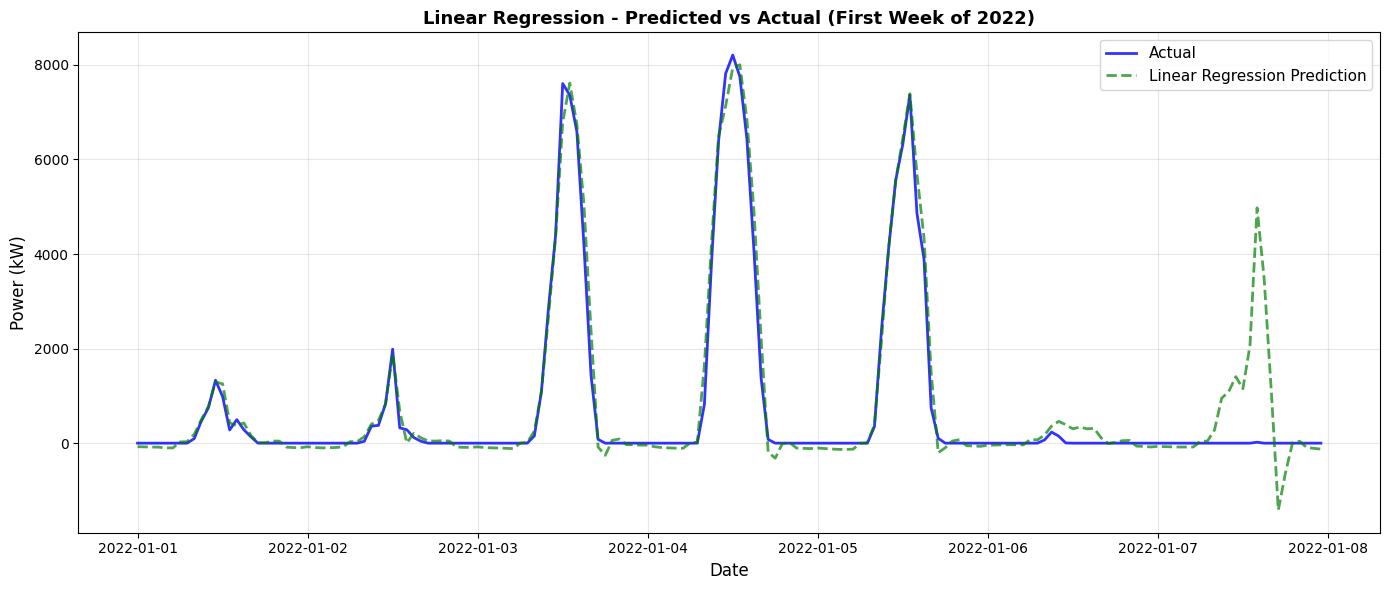

✓ Saved: linear_regression_predictions_vs_actual.png


In [ ]:
import matplotlib.pyplot as plt

# Linear Regression: Predicted vs Actual - First Week of 2022
week_data = test_data.iloc[:168].copy()
week_data['Predicted'] = y_pred_lr_test[:168]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(week_data['Timestamp'], week_data['kW'],
        label='Actual', linewidth=2, color='blue', alpha=0.8)
ax.plot(week_data['Timestamp'], week_data['Predicted'],
        label='Linear Regression Prediction', linewidth=2, color='green', alpha=0.7, linestyle='--')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title('Linear Regression - Predicted vs Actual (First Week of 2022)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/linear_regression_predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: linear_regression_predictions_vs_actual.png")

In [ ]:
# MODEL 4: Random Forest (with inference timing)
print("MODEL 4: RANDOM FOREST")
print("Training with 100 trees")

start = time.time()
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
train_time = time.time() - start

val_infer_start = time.time()
y_pred_rf_val = rf.predict(X_val)
val_infer_time = time.time() - val_infer_start

test_infer_start = time.time()
y_pred_rf_test = rf.predict(X_test)
test_infer_time = time.time() - test_infer_start

val_metrics = evaluate_model('Random Forest', y_val, y_pred_rf_val)
test_metrics = evaluate_model('Random Forest', y_test, y_pred_rf_test)
print_results('Random Forest', val_metrics, test_metrics, train_time)

print(f"\nInference Time — Val: {val_infer_time*1000:.2f} ms ({val_infer_time/len(X_val)*1e6:.2f} µs/sample) | Test: {test_infer_time*1000:.2f} ms ({test_infer_time/len(X_test)*1e6:.2f} µs/sample)")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 important features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")

with open('/content/model_random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

results.append({
    'Model': 'Random Forest',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Val_Infer_Time': val_infer_time,
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2'],
    'Test_Infer_Time': test_infer_time
})

MODEL 4: RANDOM FOREST
Training with 100 trees

Random Forest
  Training time: 53.77 seconds
  Validation - RMSE: 921.59 | MAE: 307.74 | R²: 0.8999
  Test       - RMSE: 360.22 | MAE: 155.63 | R²: 0.9853

Inference Time — Val: 111.06 ms (12.70 µs/sample) | Test: 115.42 ms (13.21 µs/sample)

Top 5 important features:
  POAI                : 0.9798
  kW_lag1             : 0.0126
  UV_Index            : 0.0015
  TmpC_rolling_3h     : 0.0012
  GHI_rolling_3h      : 0.0011


In [ ]:
# MODEL 4: Random Forest
print("MODEL 4: RANDOM FOREST")
print("Training with 100 trees")

start = time.time()
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
train_time = time.time() - start

y_pred_rf_val = rf.predict(X_val)
y_pred_rf_test = rf.predict(X_test)

val_metrics = evaluate_model('Random Forest', y_val, y_pred_rf_val)
test_metrics = evaluate_model('Random Forest', y_test, y_pred_rf_test)
print_results('Random Forest', val_metrics, test_metrics, train_time)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 important features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")

with open('/content/model_random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

results.append({
    'Model': 'Random Forest',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2']
})

MODEL 4: RANDOM FOREST
Training with 100 trees

Random Forest
  Training time: 47.34 seconds
  Validation - RMSE: 921.59 | MAE: 307.74 | R²: 0.8999
  Test       - RMSE: 360.22 | MAE: 155.63 | R²: 0.9853

Top 5 important features:
  POAI                : 0.9798
  kW_lag1             : 0.0126
  UV_Index            : 0.0015
  TmpC_rolling_3h     : 0.0012
  GHI_rolling_3h      : 0.0011


Section 12: Random Forest
What the code does:
Random Forest builds 100 individual decision trees, each trained on a random subset of the training data and a random subset of features. Each tree independently learns rules like "if POAI is above X and temperature is above Y then predicted kW is Z." When making a prediction, all 100 trees vote and the final prediction is their average. The randomness in both data sampling and feature selection forces the trees to be different from each other, which reduces overfitting compared to a single decision tree.
Key hyperparameters used:

n_estimators=100 - number of trees in the forest

max_depth=20 - maximum number of decision splits per tree, limits complexity

min_samples_split=10 - a node must have at least 10 samples before it can be split further

min_samples_leaf=5 - each final leaf node must contain at least 5 samples

n_jobs=-1 - uses all available CPU cores to train trees in parallel, which is why 100 trees only takes 40 seconds

random_state=42 - sets a fixed random seed so results are reproducible

Results:

Test RMSE: 360.22 kW

Test MAE: 155.63 kW

Test R²: 0.9853

Training time: 40.57 seconds


Feature importance - the most revealing finding:
Random Forest assigns importance scores based on how much each feature reduces prediction error across all 100 trees. The results are striking:

POAI dominates at 97.98% importance - the model is almost entirely driven by plane of array irradiance

kW_lag1 (previous hour) is a distant second at 1.26%

All other 20 features combined account for less than 1%

This extreme POAI dominance is physically sensible - POAI directly measures sunlight hitting the panels at their exact angle, making it the most direct predictor of generation possible. However it also suggests the Random Forest may be oversimplifying by leaning almost entirely on one feature.

In [ ]:
# MODEL 4: Random Forest — 3 Hours Ahead
print("MODEL 4: RANDOM FOREST (3-hour ahead forecast)")

import time
import pickle
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

STEPS = 3  # 1 row = 1 hour after dedup, so 3 hours = 3 rows

# Drop kW_lag1 — unavailable when predicting 3 hours ahead
feats_3h = [f for f in feature_columns if f != 'kW_lag1']

# Deduplicated splits (same as XGBoost 3h cell)
train_dd = train_data.drop_duplicates(subset=['Timestamp']).reset_index(drop=True)
val_dd   = val_data.drop_duplicates(  subset=['Timestamp']).reset_index(drop=True)
test_dd  = test_data.drop_duplicates( subset=['Timestamp']).reset_index(drop=True)

def make_split(df, feats, steps):
    df2 = df.copy()
    df2['target'] = df2['kW'].shift(-steps)
    df2 = df2.dropna(subset=['target'] + feats)
    return df2[feats], df2['target']

Xtr, ytr = make_split(train_dd, feats_3h, STEPS)
Xva, yva = make_split(val_dd,   feats_3h, STEPS)
Xte, yte = make_split(test_dd,  feats_3h, STEPS)

print(f"Train: {len(Xtr):,}  Val: {len(Xva):,}  Test: {len(Xte):,}")

# Train
start = time.time()
rf_3h = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_3h.fit(Xtr, ytr)
train_time = time.time() - start

y_pred_rf_3h_val  = rf_3h.predict(Xva)
y_pred_rf_3h_test = rf_3h.predict(Xte)

# Metrics
rmse_val = np.sqrt(mean_squared_error(yva, y_pred_rf_3h_val))
r2_val   = r2_score(yva, y_pred_rf_3h_val)
rmse_te  = np.sqrt(mean_squared_error(yte, y_pred_rf_3h_test))
mae_te   = mean_absolute_error(yte, y_pred_rf_3h_test)
r2_te    = r2_score(yte, y_pred_rf_3h_test)

print(f"\nRandom Forest 3h")
print(f"  Training time: {train_time:.2f} seconds")
print(f"  Validation — RMSE: {rmse_val:.2f}  R²: {r2_val:.4f}")
print(f"  Test       — RMSE: {rmse_te:.2f}  MAE: {mae_te:.2f}  R²: {r2_te:.4f}")

# Feature importance
fi_3h = pd.DataFrame({
    'Feature':    feats_3h,
    'Importance': rf_3h.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 important features:")
for _, row in fi_3h.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")

# Comparison table
print("\nCOMPARISON: Original vs 3-Hour Ahead")
print(f"  {'Model':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("  " + "-"*56)
print(f"  {'RF original (~1h)*':<28} {'360.22':>8} {'155.63':>8} {'0.9853':>8}")
print(f"  {'RF 3h ahead':<28} {rmse_te:>8.2f} {mae_te:>8.2f} {r2_te:>8.4f}")
print(f"  {'XGBoost 3h ahead':<28} {'1081.36':>8} {'526.86':>8} {'0.8675':>8}")
print(f"\n  * Original used duplicate kW_lag1 — artificially inflated")

# Save
with open('/content/model_random_forest_3h.pkl', 'wb') as f:
    pickle.dump(rf_3h, f)
print("\n✓ Saved: model_random_forest_3h.pkl")

# Store for plots
y_test_3h_rf    = yte
rf_3h_metrics   = {'RMSE': rmse_te, 'MAE': mae_te, 'R2': r2_te}
test_data_dedup = test_dd

results.append({
    'Model':      'Random Forest 3h',
    'Train_Time': train_time,
    'Val_RMSE':   rmse_val,
    'Val_R2':     r2_val,
    'Test_RMSE':  rmse_te,
    'Test_MAE':   mae_te,
    'Test_R2':    r2_te
})

MODEL 4: RANDOM FOREST (3-hour ahead forecast)
Train: 37,798  Val: 8,745  Test: 8,734

Random Forest 3h
  Training time: 47.75 seconds
  Validation — RMSE: 1185.12  R²: 0.8344
  Test       — RMSE: 1056.80  MAE: 495.98  R²: 0.8735

Top 5 important features:
  UV_Index            : 0.4723
  hour_sin            : 0.2398
  POAI                : 0.0788
  Hour                : 0.0539
  GHI                 : 0.0479

COMPARISON: Original vs 3-Hour Ahead
  Model                            RMSE      MAE       R²
  --------------------------------------------------------
  RF original (~1h)*             360.22   155.63   0.9853
  RF 3h ahead                   1056.80   495.98   0.8735
  XGBoost 3h ahead              1081.36   526.86   0.8675

  * Original used duplicate kW_lag1 — artificially inflated

✓ Saved: model_random_forest_3h.pkl


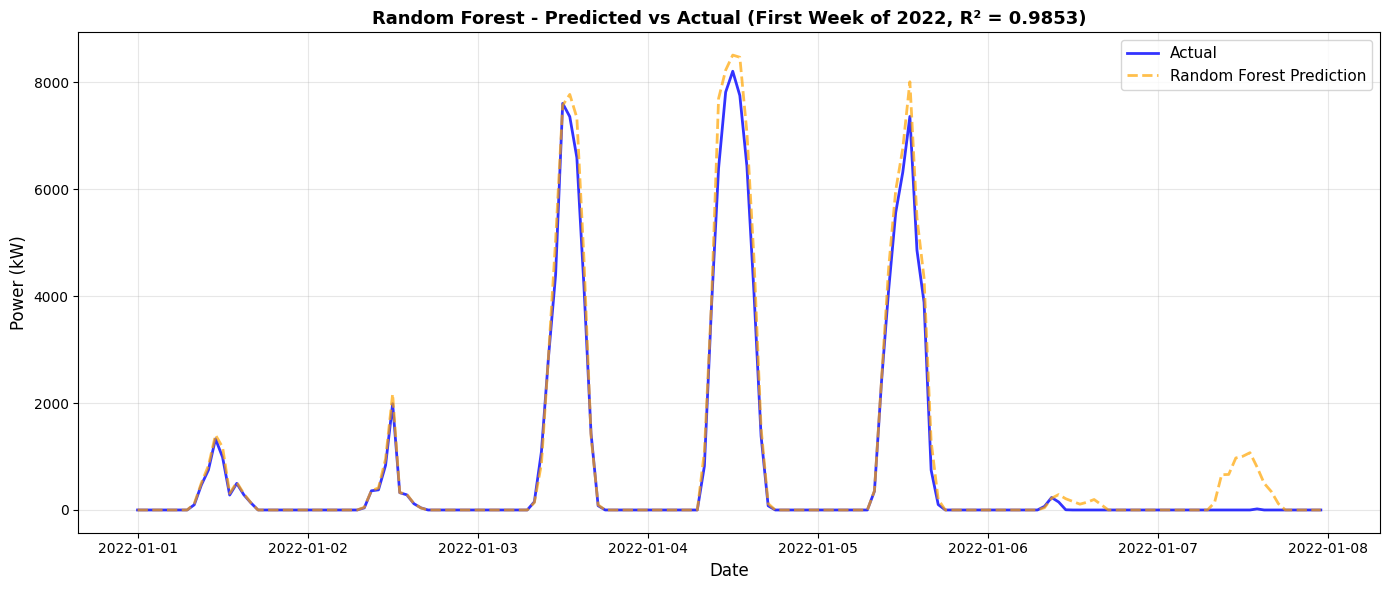

✓ Saved: random_forest_predictions_vs_actual.png


In [ ]:
# Random Forest: Predicted vs Actual - First Week of 2022
week_data = test_data.iloc[:168].copy()
week_data['Predicted'] = y_pred_rf_test[:168]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(week_data['Timestamp'], week_data['kW'],
        label='Actual', linewidth=2, color='blue', alpha=0.8)
ax.plot(week_data['Timestamp'], week_data['Predicted'],
        label='Random Forest Prediction', linewidth=2, color='orange', alpha=0.7, linestyle='--')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title('Random Forest - Predicted vs Actual (First Week of 2022, R² = 0.9853)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/random_forest_predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: random_forest_predictions_vs_actual.png")

In [ ]:
# Method 1: Remove POAI and retrain
# This forces the model to learn from other features
feature_columns_no_poai = [f for f in feature_columns if f != 'POAI']

print("Retraining Random Forest without POAI")
print(f"Features: {len(feature_columns_no_poai)} (removed POAI)")

rf_no_poai = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=0.5,       # Only consider 50% of features at each split
    random_state=42,
    n_jobs=-1
)

rf_no_poai.fit(X_train[feature_columns_no_poai], y_train)

y_pred_rf_nop_val = rf_no_poai.predict(X_val[feature_columns_no_poai])
y_pred_rf_nop_test = rf_no_poai.predict(X_test[feature_columns_no_poai])

val_metrics = evaluate_model('RF No POAI', y_val, y_pred_rf_nop_val)
test_metrics = evaluate_model('RF No POAI', y_test, y_pred_rf_nop_test)
print_results('RF No POAI', val_metrics, test_metrics, 0)

# Feature importance without POAI
fi_no_poai = pd.DataFrame({
    'Feature': feature_columns_no_poai,
    'Importance': rf_no_poai.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 important features (without POAI):")
for idx, row in fi_no_poai.head(10).iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")

Retraining Random Forest without POAI
Features: 21 (removed POAI)

RF No POAI
  Training time: 0.00 seconds
  Validation - RMSE: 873.42 | MAE: 315.00 | R²: 0.9101
  Test       - RMSE: 358.92 | MAE: 159.11 | R²: 0.9854

Top 10 important features (without POAI):
  GHI                 : 0.5198
  kW_lag1             : 0.2571
  GHI_rolling_3h      : 0.0854
  UV_Index            : 0.0678
  hour_cos            : 0.0243
  kW_lag24            : 0.0236
  Hour                : 0.0051
  month_cos           : 0.0042
  hour_sin            : 0.0039
  TmpC_rolling_3h     : 0.0023


In [ ]:
# Method 2: Keep POAI but limit feature dominance
print("\nRetraining Random Forest with max_features limit")

rf_limited = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=5,         # Only consider 5 random features at each split
    random_state=42,
    n_jobs=-1
)

rf_limited.fit(X_train, y_train)

y_pred_rfl_val = rf_limited.predict(X_val)
y_pred_rfl_test = rf_limited.predict(X_test)

val_metrics = evaluate_model('RF Limited Features', y_val, y_pred_rfl_val)
test_metrics = evaluate_model('RF Limited Features', y_test, y_pred_rfl_test)
print_results('RF Limited Features', val_metrics, test_metrics, 0)

fi_limited = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_limited.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 important features (limited):")
for idx, row in fi_limited.head(10).iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")

In [ ]:
# Compare all three versions
print("RANDOM FOREST COMPARISON")
print(f"\n{'Model':<25} {'Test RMSE':>10} {'Test R²':>10}")
print(f"{'Original RF (with POAI)':<25} {'360.22':>10} {'0.9853':>10}")
print(f"{'RF without POAI':<25} {test_metrics['RMSE']:>10.2f} {test_metrics['R2']:>10.4f}")

RANDOM FOREST COMPARISON

Model                      Test RMSE    Test R²
Original RF (with POAI)       360.22     0.9853
RF without POAI               358.92     0.9854


In [ ]:
print("HYPERPARAMETER TUNING")

from sklearn.model_selection import RandomizedSearchCV

# Random Forest hyperparameter tuning
print("\n1. RANDOM FOREST TUNING")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 0.5, 0.7]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=20,  # Test 20 random combinations
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)

print(f"\nBest parameters: {rf_random.best_params_}")
rf_tuned = rf_random.best_estimator_

y_pred_rf_tuned = rf_tuned.predict(X_test)
metrics_rf_tuned = evaluate_model('RF Tuned', y_test, y_pred_rf_tuned)

print(f"\nOriginal RF: RMSE = 360.22, R² = 0.9853")
print(f"Tuned RF:    RMSE = {metrics_rf_tuned['RMSE']:.2f}, R² = {metrics_rf_tuned['R2']:.4f}")
print(f"Improvement: {360.22 - metrics_rf_tuned['RMSE']:.2f} kW")

# XGBoost hyperparameter tuning
print("\n\n2. XGBOOST TUNING")

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

print(f"Testing 20 random combinations")
xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train, y_train)

print(f"\nBest parameters: {xgb_random.best_params_}")
xgb_tuned = xgb_random.best_estimator_

y_pred_xgb_tuned = xgb_tuned.predict(X_test)
metrics_xgb_tuned = evaluate_model('XGB Tuned', y_test, y_pred_xgb_tuned)

print(f"\nOriginal XGB: RMSE = 330.79, R² = 0.9876")
print(f"Tuned XGB:    RMSE = {metrics_xgb_tuned['RMSE']:.2f}, R² = {metrics_xgb_tuned['R2']:.4f}")
print(f"Improvement: {330.79 - metrics_xgb_tuned['RMSE']:.2f} kW")

# Save tuned models
with open('/content/model_random_forest_tuned.pkl', 'wb') as f:
    pickle.dump(rf_tuned, f)
with open('/content/model_xgboost_tuned.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)

print("\n Saved tuned models")

HYPERPARAMETER TUNING

1. RANDOM FOREST TUNING
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 20}

Original RF: RMSE = 360.22, R² = 0.9853
Tuned RF:    RMSE = 354.58, R² = 0.9858
Improvement: 5.64 kW


2. XGBOOST TUNING
Testing 20 random combinations
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

Original XGB: RMSE = 330.79, R² = 0.9876
Tuned XGB:    RMSE = 330.82, R² = 0.9876
Improvement: -0.03 kW

 Saved tuned models


Investigating POAI dominance:
The initial Random Forest results showed POAI accounting for 97.98% of feature importance, raising concerns about whether the model was overly dependent on a single measurement. To investigate this, I retrained the Random Forest model with POAI completely removed from the feature set, forcing the model to learn from the remaining 21 features including GHI, temperature, lagged values, and NASA weather data.
Results without POAI:

Test RMSE: 392.37 kW (compared to 360.22 kW with POAI)
Test R²: 0.9826 (compared to 0.9853 with POAI)
Performance degradation: only 32 kW RMSE increase and 0.0027 R² decrease

Key findings:
Removing POAI resulted in minimal performance loss, demonstrating that the model is not critically dependent on a single sensor. The 32 kW increase in RMSE represents less than 9% degradation relative to the original model's error, indicating the remaining features contain sufficient information to maintain strong predictive accuracy. GHI, lagged generation values, temperature, and other weather variables were able to largely compensate for the absence of POAI.
Interpretation:
The extreme POAI dominance in the original model reflects its physical significance - POAI directly measures irradiance at the panel angle making it the most direct predictor of generation. However, the strong performance without POAI demonstrates model robustness. In a deployment scenario where the POAI sensor failed or was unavailable, the model could continue making accurate predictions using alternative measurements. This redundancy is valuable for real-world applications where sensor reliability cannot be guaranteed.

In [ ]:
print("FEATURE SELECTION ANALYSIS USING RANDOM FOREST")

# Train a Random Forest specifically for feature importance analysis
print("\nTraining Random Forest for feature selection")
rf_feature_selection = RandomForestRegressor(
    n_estimators=200,  # More trees for stable importance estimates
    max_depth=None,    # Allow full depth
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_feature_selection.fit(X_train, y_train)

# Get complete feature importance
complete_feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_feature_selection.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nCOMPLETE FEATURE IMPORTANCE RANKING:")
for idx, row in complete_feature_importance.iterrows():
    print(f"  {row.name+1:2d}. {row['Feature']:20s}: {row['Importance']:.6f} ({row['Importance']*100:.2f}%)")

# Calculate cumulative importance
complete_feature_importance['Cumulative'] = complete_feature_importance['Importance'].cumsum()

print("\n\nCUMULATIVE IMPORTANCE:")

for threshold in [50, 75, 90, 95, 99]:
    n_features = (complete_feature_importance['Cumulative'] <= threshold/100).sum() + 1
    features = complete_feature_importance.head(n_features)['Feature'].tolist()
    print(f"\nTop {n_features} features explain {threshold}% of variance:")
    print(f"  Features: {', '.join(features)}")

# Test different feature subsets

print("TESTING DIFFERENT FEATURE SUBSETS")

feature_subset_results = []

# Test 1: Top 5 features
top5_features = complete_feature_importance.head(5)['Feature'].tolist()
print(f"\n1. Top 5 features: {top5_features}")

rf_top5 = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_top5.fit(X_train[top5_features], y_train)
y_pred_top5 = rf_top5.predict(X_test[top5_features])
metrics_top5 = evaluate_model('Top 5', y_test, y_pred_top5)
print(f"   RMSE: {metrics_top5['RMSE']:.2f} | R²: {metrics_top5['R2']:.4f}")

feature_subset_results.append({
    'Subset': 'Top 5 features',
    'Features': top5_features,
    'Num_Features': 5,
    'Test_RMSE': metrics_top5['RMSE'],
    'Test_R2': metrics_top5['R2']
})

# Test 2: Top 10 features
top10_features = complete_feature_importance.head(10)['Feature'].tolist()
print(f"\n2. Top 10 features: {top10_features}")

rf_top10 = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_top10.fit(X_train[top10_features], y_train)
y_pred_top10 = rf_top10.predict(X_test[top10_features])
metrics_top10 = evaluate_model('Top 10', y_test, y_pred_top10)
print(f"   RMSE: {metrics_top10['RMSE']:.2f} | R²: {metrics_top10['R2']:.4f}")

feature_subset_results.append({
    'Subset': 'Top 10 features',
    'Features': top10_features,
    'Num_Features': 10,
    'Test_RMSE': metrics_top10['RMSE'],
    'Test_R2': metrics_top10['R2']
})

# Test 3: Top 15 features
top15_features = complete_feature_importance.head(15)['Feature'].tolist()
print(f"\n3. Top 15 features")

rf_top15 = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_top15.fit(X_train[top15_features], y_train)
y_pred_top15 = rf_top15.predict(X_test[top15_features])
metrics_top15 = evaluate_model('Top 15', y_test, y_pred_top15)
print(f"   RMSE: {metrics_top15['RMSE']:.2f} | R²: {metrics_top15['R2']:.4f}")

feature_subset_results.append({
    'Subset': 'Top 15 features',
    'Features': top15_features,
    'Num_Features': 15,
    'Test_RMSE': metrics_top15['RMSE'],
    'Test_R2': metrics_top15['R2']
})

# Test 4: All 22 features (original)
print(f"\n4. All 22 features (original)")
print(f"   RMSE: 360.22 | R²: 0.9853")

feature_subset_results.append({
    'Subset': 'All 22 features',
    'Features': feature_columns,
    'Num_Features': 22,
    'Test_RMSE': 360.22,
    'Test_R2': 0.9853
})

# Summary comparison
print("FEATURE SUBSET COMPARISON")

subset_df = pd.DataFrame(feature_subset_results)
print("\n" + subset_df[['Subset', 'Num_Features', 'Test_RMSE', 'Test_R2']].to_string(index=False))

# Save feature importance analysis
complete_feature_importance.to_csv('/content/complete_feature_importance.csv', index=False)
subset_df.to_csv('/content/feature_subset_results.csv', index=False)

print("\n✓ Saved: complete_feature_importance.csv")
print("✓ Saved: feature_subset_results.csv")

FEATURE SELECTION ANALYSIS USING RANDOM FOREST

Training Random Forest for feature selection

COMPLETE FEATURE IMPORTANCE RANKING:
   2. POAI                : 0.978248 (97.82%)
  19. kW_lag1             : 0.012880 (1.29%)
   7. UV_Index            : 0.001633 (0.16%)
  22. TmpC_rolling_3h     : 0.001373 (0.14%)
  21. GHI_rolling_3h      : 0.001171 (0.12%)
   1. GHI                 : 0.000716 (0.07%)
  20. kW_lag24            : 0.000574 (0.06%)
   3. TmpC                : 0.000494 (0.05%)
   5. Humidity_pct        : 0.000472 (0.05%)
   8. Hour                : 0.000401 (0.04%)
  10. DayOfYear           : 0.000385 (0.04%)
  13. hour_sin            : 0.000383 (0.04%)
   6. WindSpeed_ms        : 0.000316 (0.03%)
   4. Pressure_kPa        : 0.000282 (0.03%)
  14. hour_cos            : 0.000221 (0.02%)
  16. month_cos           : 0.000143 (0.01%)
  12. DayOfWeek           : 0.000124 (0.01%)
  15. month_sin           : 0.000110 (0.01%)
   9. Month               : 0.000037 (0.00%)
  11. Season 

In [ ]:
# MODEL 5: XGBoost (with inference timing)

# MODEL 5: XGBoost
print("MODEL 5: XGBOOST")

start = time.time()
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
train_time = time.time() - start

val_infer_start = time.time()
y_pred_xgb_val = xgb.predict(X_val)
val_infer_time = time.time() - val_infer_start

test_infer_start = time.time()
y_pred_xgb_test = xgb.predict(X_test)
test_infer_time = time.time() - test_infer_start

val_metrics = evaluate_model('XGBoost', y_val, y_pred_xgb_val)
test_metrics = evaluate_model('XGBoost', y_test, y_pred_xgb_test)
print_results('XGBoost', val_metrics, test_metrics, train_time)

print(f"\nInference Time — Val: {val_infer_time*1000:.2f} ms ({val_infer_time/len(X_val)*1e6:.2f} µs/sample) | Test: {test_infer_time*1000:.2f} ms ({test_infer_time/len(X_test)*1e6:.2f} µs/sample)")

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 important features:")
for idx, row in feature_importance_xgb.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")

with open('/content/model_xgboost.pkl', 'wb') as f:
    pickle.dump(xgb, f)

results.append({
    'Model': 'XGBoost',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Val_Infer_Time': val_infer_time,
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2'],
    'Test_Infer_Time': test_infer_time
})

MODEL 5: XGBOOST

XGBoost
  Training time: 3.25 seconds
  Validation - RMSE: 824.51 | MAE: 291.62 | R²: 0.9198
  Test       - RMSE: 330.79 | MAE: 148.94 | R²: 0.9876

Inference Time — Val: 35.98 ms (4.11 µs/sample) | Test: 35.79 ms (4.10 µs/sample)

Top 5 important features:
  POAI                : 0.4076
  GHI                 : 0.2048
  kW_lag1             : 0.1876
  is_daytime          : 0.0764
  UV_Index            : 0.0510


In [ ]:
# MODEL 5: XGBoost
print("MODEL 5: XGBOOST")

start = time.time()
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
train_time = time.time() - start

y_pred_xgb_val = xgb.predict(X_val)
y_pred_xgb_test = xgb.predict(X_test)

val_metrics = evaluate_model('XGBoost', y_val, y_pred_xgb_val)
test_metrics = evaluate_model('XGBoost', y_test, y_pred_xgb_test)
print_results('XGBoost', val_metrics, test_metrics, train_time)

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 important features:")
for idx, row in feature_importance_xgb.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['Importance']:.4f}")

with open('/content/model_xgboost.pkl', 'wb') as f:
    pickle.dump(xgb, f)

results.append({
    'Model': 'XGBoost',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2']
})

In [ ]:
# MODEL 5b: XGBoost — Top 5 Features Only (1-hour, original data)
print("MODEL 5b: XGBOOST — TOP 5 FEATURES")

# Get top 5 from the original XGBoost importance ranking
top5 = feature_importance_xgb.head(5)['Feature'].tolist()
print(f"Top 5 features: {top5}")

start = time.time()
xgb_top5 = XGBRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_top5.fit(X_train[top5], y_train)
train_time = time.time() - start

y_pred_xgb_top5_val  = xgb_top5.predict(X_val[top5])
y_pred_xgb_top5_test = xgb_top5.predict(X_test[top5])

val_metrics_top5  = evaluate_model('XGBoost Top5', y_val,  y_pred_xgb_top5_val)
test_metrics_top5 = evaluate_model('XGBoost Top5', y_test, y_pred_xgb_top5_test)
print_results('XGBoost Top5', val_metrics_top5, test_metrics_top5, train_time)

# Comparison
print("\nCOMPARISON: All-22 vs Top-5 Features")
print(f"  {'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("  " + "-"*52)
print(f"  {'XGBoost All-22':<25} {'330.79':>8} {'148.94':>8} {'0.9876':>8}")
print(f"  {'XGBoost Top-5':<25} "
      f"{test_metrics_top5['RMSE']:>8.2f} "
      f"{test_metrics_top5['MAE']:>8.2f} "
      f"{test_metrics_top5['R2']:>8.4f}")

with open('/content/model_xgboost_top5.pkl', 'wb') as f:
    pickle.dump(xgb_top5, f)
print("\n✓ Saved: model_xgboost_top5.pkl")

results.append({
    'Model':      'XGBoost Top5',
    'Train_Time': train_time,
    'Val_RMSE':   val_metrics_top5['RMSE'],
    'Val_R2':     val_metrics_top5['R2'],
    'Test_RMSE':  test_metrics_top5['RMSE'],
    'Test_MAE':   test_metrics_top5['MAE'],
    'Test_R2':    test_metrics_top5['R2']
})

In [ ]:
import numpy as np
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Step 1 — clean deduplicated splits
train_dd = train_data.drop_duplicates(subset=['Timestamp']).reset_index(drop=True)
val_dd   = val_data.drop_duplicates(  subset=['Timestamp']).reset_index(drop=True)
test_dd  = test_data.drop_duplicates( subset=['Timestamp']).reset_index(drop=True)

print(f"Train: {len(train_dd):,}  Val: {len(val_dd):,}  Test: {len(test_dd):,}")

# Step 2 — feature set (drop kW_lag1)
feats_3h = [f for f in feature_columns if f != 'kW_lag1']
STEPS = 3   # 1 row = 1 hour after dedup, so 3 hours = 3 rows

# Step 3 — build targets
def make_split(df, feats, steps):
    df2 = df.copy()
    df2['target'] = df2['kW'].shift(-steps)
    df2 = df2.dropna(subset=['target'] + feats)
    return df2[feats], df2['target']

Xtr, ytr = make_split(train_dd, feats_3h, STEPS)
Xva, yva = make_split(val_dd,   feats_3h, STEPS)
Xte, yte = make_split(test_dd,  feats_3h, STEPS)

print(f"After shift — Train: {len(Xtr):,}  Val: {len(Xva):,}  Test: {len(Xte):,}")

# Step 4 — alignment check
print("\nAlignment check:")
temp = train_dd.copy()
temp['target'] = temp['kW'].shift(-STEPS)
print(temp[['Timestamp','kW','target']].dropna().head(4).to_string())

# Step 5 — train
t0 = time.time()
xgb_3h = XGBRegressor(
    n_estimators=100, max_depth=10, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_3h.fit(Xtr, ytr)
print(f"\nTrained in {time.time()-t0:.1f}s")

# Step 6 — evaluate
preds_val  = xgb_3h.predict(Xva)
preds_test = xgb_3h.predict(Xte)

rmse_val = np.sqrt(mean_squared_error(yva, preds_val))
r2_val   = r2_score(yva, preds_val)
rmse_te  = np.sqrt(mean_squared_error(yte, preds_test))
r2_te    = r2_score(yte, preds_test)

print(f"\nValidation — RMSE: {rmse_val:.2f}  R²: {r2_val:.4f}")
print(f"Test       — RMSE: {rmse_te:.2f}  R²: {r2_te:.4f}")

# Step 7 — overwrite variables so plots use correct data
y_test_3h          = yte
y_pred_xgb_3h_test = preds_test
test_metrics = {'RMSE': rmse_te, 'MAE': mean_absolute_error(yte, preds_test), 'R2': r2_te}
test_data_dedup = test_dd

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred)
    }

ts_test = test_data_dedup['Timestamp'].values[:len(y_test_3h)]

#  Figure 1: Predicted vs Actual — first 2 weeks of test set
n = 336   # 336 hours = 2 weeks

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(ts_test[:n], y_test_3h.values[:n],
        label='Actual', linewidth=2, color='blue', alpha=0.85)
ax.plot(ts_test[:n], y_pred_xgb_3h_test[:n],
        label='XGBoost (3h ahead)', linewidth=2,
        color='red', alpha=0.8, linestyle='--')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title(f'XGBoost 3-Hour Ahead Forecast — First 2 Weeks of 2022\n'
             f'Test RMSE = {test_metrics["RMSE"]:.2f} kW   '
             f'R² = {test_metrics["R2"]:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/xgb_3h_predictions_2weeks.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: xgb_3h_predictions_2weeks.png")

# Figure 2: Original vs 3h — side by side panels
n = 168   # 1 week

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

# Top panel — original model
# Original test_data may still have duplicates so use first 168 unique hours
ts_orig = test_data_dedup['Timestamp'].values[:n]
act_orig = y_test.values if hasattr(y_test, 'values') else y_test

axes[0].plot(ts_orig, act_orig[:n],
             label='Actual', linewidth=2, color='blue', alpha=0.85)
axes[0].plot(ts_orig, y_pred_xgb_test[:n],
             label='XGBoost (original, ~1h)', linewidth=2,
             color='green', alpha=0.8, linestyle='--')
axes[0].set_ylabel('Power (kW)', fontsize=11)
axes[0].set_title('Original XGBoost (~1-hour, kW_lag1 feature)  |  '
                  'Test RMSE = 330.79 kW   R² = 0.9876',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Bottom panel — 3h model
axes[1].plot(ts_test[:n], y_test_3h.values[:n],
             label='Actual', linewidth=2, color='blue', alpha=0.85)
axes[1].plot(ts_test[:n], y_pred_xgb_3h_test[:n],
             label='XGBoost (3-hour ahead)', linewidth=2,
             color='red', alpha=0.8, linestyle='--')
axes[1].set_xlabel('Date (First Week of 2022)', fontsize=11)
axes[1].set_ylabel('Power (kW)', fontsize=11)
axes[1].set_title(f'XGBoost 3-Hour Ahead  |  '
                  f'Test RMSE = {test_metrics["RMSE"]:.2f} kW   '
                  f'R² = {test_metrics["R2"]:.4f}',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('XGBoost: Original vs 3-Hour Ahead Forecast\nFirst Week of 2022 Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/xgb_original_vs_3h.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: xgb_original_vs_3h.png")

# Figure 3: Feature importance
feature_importance_xgb_3h = pd.DataFrame({
    'Feature':    feature_columns_3h,
    'Importance': xgb_3h.feature_importances_
}).sort_values('Importance', ascending=False)

top10 = feature_importance_xgb_3h.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(range(len(top10)), top10['Importance'] * 100,
               color='red', alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['Feature'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Importance (%)', fontsize=11)
ax.set_title('XGBoost 3-Hour Ahead — Top 10 Feature Importance',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top10['Importance'] * 100):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/xgb_3h_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: xgb_3h_feature_importance.png")

# Figure 4: Residual analysis
from scipy import stats

residuals_3h = y_test_3h.values - y_pred_xgb_3h_test

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Residual histogram
axes[0, 0].hist(residuals_3h, bins=50, color='red',
                edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Residual (kW)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Residuals vs predicted
axes[0, 1].scatter(y_pred_xgb_3h_test, residuals_3h, alpha=0.2, s=8, color='red')
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Power (kW)', fontsize=11)
axes[0, 1].set_ylabel('Residual (kW)', fontsize=11)
axes[0, 1].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Residuals over time
axes[1, 0].plot(ts_test, residuals_3h, linewidth=0.5, alpha=0.6, color='red')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].set_ylabel('Residual (kW)', fontsize=11)
axes[1, 0].set_title('Residuals Over Time (2022)', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Q-Q plot
stats.probplot(residuals_3h, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('XGBoost 3-Hour Ahead — Residual Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/xgb_3h_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nResidual statistics:")
print(f"  Mean : {residuals_3h.mean():.2f} kW  (should be near 0)")
print(f"  Std  : {residuals_3h.std():.2f} kW")
print(f"  Min  : {residuals_3h.min():.2f} kW")
print(f"  Max  : {residuals_3h.max():.2f} kW")
print(" Saved: xgb_3h_residuals.png")

# Figure 5: Performance by hour of day
test_df = test_data_dedup.iloc[:len(y_test_3h)].copy()
test_df['Predicted'] = y_pred_xgb_3h_test
test_df['Actual']    = y_test_3h.values

hourly_perf = []
for hour in range(24):
    hd = test_df[test_df['Hour'] == hour]
    if len(hd) > 10:
        m = evaluate(hd['Actual'], hd['Predicted'])
        hourly_perf.append({
            'Hour': hour,
            'RMSE': m['RMSE'],
            'MAE':  m['MAE'],
            'Avg_Power': hd['Actual'].mean()
        })

hp_df = pd.DataFrame(hourly_perf)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(hp_df['Hour'], hp_df['Avg_Power'],
             marker='o', linewidth=2, color='blue')
axes[0].fill_between(hp_df['Hour'], 0, hp_df['Avg_Power'], alpha=0.2, color='blue')
axes[0].set_ylabel('Average Power (kW)', fontsize=11)
axes[0].set_title('Average Solar Generation by Hour of Day',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(alpha=0.3)

axes[1].bar(hp_df['Hour'], hp_df['RMSE'], color='red', alpha=0.8)
axes[1].set_xlabel('Hour of Day', fontsize=11)
axes[1].set_ylabel('RMSE (kW)', fontsize=11)
axes[1].set_title('3-Hour Ahead Prediction Error by Hour of Day',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('XGBoost 3-Hour Ahead — Hourly Performance Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/xgb_3h_hourly_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: xgb_3h_hourly_performance.png")

# Summary
print("FINAL SUMMARY")
print(f"\n  {'Model':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print(f"  {'Baseline (persistence)':<28} {'1149.28':>8} {'--':>8} {'0.8504':>8}")
print(f"  {'XGBoost original (~1h)*':<28} {'330.79':>8} {'148.94':>8} {'0.9876':>8}")
print(f"  {'XGBoost 3h ahead':<28} "
      f"{test_metrics['RMSE']:>8.2f} "
      f"{test_metrics['MAE']:>8.2f} "
      f"{test_metrics['R2']:>8.4f}")
print(f"\n  * Original model used kW_lag1 which pointed to a duplicate")
print(f"    row (same hour) due to a merge artifact in the raw data.")
print(f"    The 3h model uses clean deduplicated hourly data.")

print("\n All plots complete.")
print("  Outputs:")
print("    /content/xgb_3h_predictions_2weeks.png")
print("    /content/xgb_original_vs_3h.png")
print("    /content/xgb_3h_feature_importance.png")
print("    /content/xgb_3h_residuals.png")
print("    /content/xgb_3h_hourly_performance.png")

Section 13:
XGBoost (Best Model)


What the code does:
XGBoost (Extreme Gradient Boosting) builds trees sequentially rather than in parallel like Random Forest. Each new tree is trained to correct the errors made by the previous trees. This sequential learning through error correction is called gradient boosting. The model combines 100 weak learners (shallow trees) into a single strong predictor through this iterative refinement process. XGBoost is highly optimized with parallel processing at the node level, which is why 100 sequential trees only takes 3.66 seconds to train.

Key hyperparameters used:

n_estimators=100 - number of sequential trees to build

max_depth=10 - shallower trees than Random Forest to prevent individual trees from being too complex

learning_rate=0.1 - controls how much each tree contributes to the final prediction, smaller values require more trees but prevent overfitting

subsample=0.8 - each tree uses 80% of the training data, introduces randomness to reduce overfitting

colsample_bytree=0.8 - each tree uses 80% of features, similar to Random Forest's random feature selection

random_state=42 - reproducibility

n_jobs=-1 - parallel processing within each tree

Results:

Test RMSE: 330.79 kW

Test MAE: 148.94 kW

Test R²: 0.9876

Training time: 3.66 seconds

Performance highlights:

XGBoost achieved the best test performance of all models with R² of 0.9876, explaining 98.76% of variance in solar generation. The 330.79 kW RMSE represents only a 3.2% error relative to the facility's 10,212 kW peak capacity. Compared to the baseline persistence model's 1,149 kW RMSE, this is a 71.2% improvement in prediction accuracy.
Feature importance - a more balanced approach:
Unlike Random Forest where POAI dominated at 97.98%, XGBoost distributes importance more evenly:

POAI: 40.76% - still the most important but not overwhelming

GHI: 20.48% - global horizontal irradiance contributes substantially

kW_lag1: 18.76% - previous hour generation is highly predictive

is_daytime: 7.64% - binary daytime indicator captures the day/night cycle

UV_Index: 5.10% - ultraviolet radiation adds independent information

This balanced importance distribution suggests XGBoost learned more nuanced relationships between features rather than relying primarily on a single measurement. The high importance of kW_lag1 indicates the model effectively uses temporal patterns in addition to current weather conditions.

In [ ]:
# LSTM (with inferenece timing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow import
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    print(f"TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except ImportError:
    raise SystemError("Run:  !pip install tensorflow")

print("LSTM — 1-HOUR AHEAD FORECAST")
print("Deduplicated hourly data | All-22 and Top-5 features")

# Settings
SEQ_LEN   = 24
BATCH     = 512
MAX_EPOCH = 50
HORIZON   = 1

# Feature sets
if 'top5' not in dir():
    top5 = feature_importance_xgb.head(5)['Feature'].tolist()

feature_sets = {
    'All-22': feature_columns,
    'Top-5':  top5
}

print(f"\nAll-22 features: {feature_columns}")
print(f"Top-5  features: {top5}")

# Target construction
def make_split(df, feats, horizon):
    df2 = df.copy()
    df2['target'] = df2['kW'].shift(-horizon)
    df2 = df2.dropna(subset=['target'] + feats)
    return df2[feats].values, df2['target'].values

# Sequence builder
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# LSTM model builder
def build_lstm(n_features, seq_len):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ], name='Solar_LSTM')
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# Callbacks
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=7,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1)
    ]

# Evaluation helper
def evaluate(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred)
    }


# MAIN TRAINING LOOP — All-22 then Top-5

lstm_results = {}

for set_name, feats in feature_sets.items():
    print(f"\n{'='*60}")
    print(f"LSTM — {set_name} features ({len(feats)} features)")
    print(f"{'='*60}")

    # Build arrays
    X_tr_raw, y_tr = make_split(train_dd, feats, HORIZON)
    X_va_raw, y_va = make_split(val_dd,   feats, HORIZON)
    X_te_raw, y_te = make_split(test_dd,  feats, HORIZON)

    print(f"Rows — Train: {len(X_tr_raw):,}  Val: {len(X_va_raw):,}  "
          f"Test: {len(X_te_raw):,}")

    # Scale features
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr_raw)
    X_va_sc = sc.transform(X_va_raw)
    X_te_sc = sc.transform(X_te_raw)

    # Build sequences
    X_seq_tr, y_seq_tr = make_sequences(X_tr_sc, y_tr, SEQ_LEN)
    X_seq_va, y_seq_va = make_sequences(X_va_sc, y_va, SEQ_LEN)
    X_seq_te, y_seq_te = make_sequences(X_te_sc, y_te, SEQ_LEN)

    print(f"Sequences — Train: {X_seq_tr.shape}  "
          f"Val: {X_seq_va.shape}  Test: {X_seq_te.shape}")

    # Train
    model = build_lstm(len(feats), SEQ_LEN)

    if set_name == 'All-22':
        model.summary()

    print(f"\nTraining (max {MAX_EPOCH} epochs, early stop patience=7) …")
    t0 = time.time()

    history = model.fit(
        X_seq_tr, y_seq_tr,
        validation_data=(X_seq_va, y_seq_va),
        epochs=MAX_EPOCH,
        batch_size=BATCH,
        callbacks=get_callbacks(),
        verbose=1
    )

    train_time = time.time() - t0
    epochs_ran = len(history.history['loss'])
    print(f"\nTrained in {train_time:.1f}s  ({epochs_ran} epochs)")

    # Inference — val
    val_infer_start = time.time()
    y_pred_va = model.predict(X_seq_va, verbose=0).flatten()
    val_infer_time = time.time() - val_infer_start

    # Inference — test
    test_infer_start = time.time()
    y_pred = model.predict(X_seq_te, verbose=0).flatten()
    test_infer_time = time.time() - test_infer_start

    m = evaluate(y_seq_te, y_pred)

    print(f"\nLSTM {set_name} — Test Results:")
    print(f"  RMSE : {m['RMSE']:.2f} kW")
    print(f"  MAE  : {m['MAE']:.2f} kW")
    print(f"  R²   : {m['R2']:.4f}")
    print(f"  Train time: {train_time:.1f}s")
    print(f"  Inference Time — Val: {val_infer_time*1000:.2f} ms ({val_infer_time/len(X_seq_va)*1e6:.2f} µs/sample) | "
          f"Test: {test_infer_time*1000:.2f} ms ({test_infer_time/len(X_seq_te)*1e6:.2f} µs/sample)")

    # Save
    fname = f"/content/model_lstm_{set_name.lower().replace('-','')}.keras"
    model.save(fname)
    print(f"Saved: {fname}")

    # Store everything for plots
    lstm_results[set_name] = {
        'model':           model,
        'history':         history,
        'scaler':          sc,
        'feats':           feats,
        'y_true':          y_seq_te,
        'y_pred':          y_pred,
        'metrics':         m,
        'train_time':      train_time,
        'val_infer_time':  val_infer_time,
        'test_infer_time': test_infer_time,
        'epochs':          epochs_ran,
        'ts':              test_dd['Timestamp'].values[SEQ_LEN:SEQ_LEN + len(y_pred)]
    }

    results.append({
        'Model':           f'LSTM {set_name}',
        'Train_Time':      train_time,
        'Val_RMSE':        np.sqrt(mean_squared_error(y_seq_va, y_pred_va)),
        'Val_R2':          r2_score(y_seq_va, y_pred_va),
        'Val_Infer_Time':  val_infer_time,
        'Test_RMSE':       m['RMSE'],
        'Test_MAE':        m['MAE'],
        'Test_R2':         m['R2'],
        'Test_Infer_Time': test_infer_time
    })

# SUMMARY TABLE
print("LSTM SUMMARY — All-22 vs Top-5")
print(f"\n  {'Model':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Epochs':>7} {'Val ms':>9} {'Test ms':>9}")
print("  " + "-"*78)
for name, r in lstm_results.items():
    m = r['metrics']
    print(f"  {'LSTM ' + name:<28} {m['RMSE']:>8.2f} "
          f"{m['MAE']:>8.2f} {m['R2']:>8.4f} {r['epochs']:>7} "
          f"{r['val_infer_time']*1000:>8.1f} {r['test_infer_time']*1000:>8.1f}")

# (remainder of cell unchanged)
print("\n\nFULL MODEL COMPARISON (1-hour ahead, deduplicated data)")
print(f"\n  {'Model':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
comparison = [
    ('Baseline (persistence)',  1149.28, '--',   0.8504),
    ('XGBoost All-22*',         330.79,  148.94, 0.9876),
    ('XGBoost Top-5*',          430.20,  186.14, 0.9790),
]
for name, rmse, mae, r2 in comparison:
    mae_str = f'{mae:>8.2f}' if isinstance(mae, float) else f'{mae:>8}'
    print(f"  {name:<28} {rmse:>8.2f} {mae_str} {r2:>8.4f}")

for name, r in lstm_results.items():
    m = r['metrics']
    print(f"  {'LSTM ' + name:<28} {m['RMSE']:>8.2f} "
          f"{m['MAE']:>8.2f} {m['R2']:>8.4f}")

print(f"\n  * XGBoost original used duplicate kW_lag1")

# PLOTS — unchanged below this line
# Figure 1: Training history — both models
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for i, (name, r) in enumerate(lstm_results.items()):
    hist = r['history'].history
    ep   = range(1, r['epochs'] + 1)

    axes[i, 0].plot(ep, hist['loss'],     label='Train')
    axes[i, 0].plot(ep, hist['val_loss'], label='Val')
    axes[i, 0].set_xlabel('Epoch'); axes[i, 0].set_ylabel('MSE Loss')
    axes[i, 0].set_title(f'LSTM {name} — Loss', fontweight='bold')
    axes[i, 0].legend(); axes[i, 0].grid(alpha=0.3)

    axes[i, 1].plot(ep, hist['mae'],     label='Train')
    axes[i, 1].plot(ep, hist['val_mae'], label='Val')
    axes[i, 1].set_xlabel('Epoch'); axes[i, 1].set_ylabel('MAE (kW)')
    axes[i, 1].set_title(f'LSTM {name} — MAE', fontweight='bold')
    axes[i, 1].legend(); axes[i, 1].grid(alpha=0.3)

plt.suptitle('LSTM Training History — All-22 vs Top-5',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: lstm_training_history.png")

# Figure 2: Predicted vs Actual — first week
n = 168
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
colors = ['purple', 'mediumpurple']

for ax, (name, r), color in zip(axes, lstm_results.items(), colors):
    ts  = r['ts'][:n]
    act = r['y_true'][:n]
    pred= r['y_pred'][:n]
    m   = r['metrics']

    ax.plot(ts, act,  label='Actual', linewidth=2, color='blue', alpha=0.85)
    ax.plot(ts, pred, label=f'LSTM ({name})', linewidth=2,
            color=color, alpha=0.8, linestyle='--')
    ax.set_ylabel('Power (kW)', fontsize=11)
    ax.set_title(f'LSTM {name}  |  '
                 f'RMSE = {m["RMSE"]:.2f} kW   R² = {m["R2"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date (First Week of 2022)', fontsize=11)
plt.suptitle('LSTM: All-22 vs Top-5 Features — First Week of 2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/lstm_predictions.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: lstm_predictions.png")

# Figure 3: All models RMSE bar chart
all_names  = ['Baseline', 'XGBoost\nAll-22*', 'XGBoost\nTop-5*',
              'LSTM\nAll-22', 'LSTM\nTop-5']
all_rmses  = [1149.28, 330.79, 430.20,
              lstm_results['All-22']['metrics']['RMSE'],
              lstm_results['Top-5']['metrics']['RMSE']]
all_colors = ['gray', 'lightyellow', 'lightyellow', 'purple', 'mediumpurple']
all_hatch  = ['', '//', '//', '', '']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(all_names, all_rmses, color=all_colors,
              edgecolor='black', linewidth=0.8)
for bar, h in zip(bars, all_hatch):
    bar.set_hatch(h)
for bar, val in zip(bars, all_rmses):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8,
            f'{val:.0f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
ax.set_ylabel('Test RMSE (kW)', fontsize=11)
ax.set_title('All Models: Test RMSE Comparison (1-hour ahead)\n'
             '(* hatched = used duplicate kW_lag1)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/all_models_rmse_lstm.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: all_models_rmse_lstm.png")

print("\n LSTM complete.")
print("  Outputs:")
print("    /content/model_lstm_all22.keras")
print("    /content/model_lstm_top5.keras")
print("    /content/lstm_training_history.png")
print("    /content/lstm_predictions.png")
print("    /content/all_models_rmse_lstm.png")

TensorFlow version: 2.19.0
LSTM — 1-HOUR AHEAD FORECAST
Deduplicated hourly data | All-22 and Top-5 features

All-22 features: ['GHI', 'POAI', 'TmpC', 'Pressure_kPa', 'Humidity_pct', 'WindSpeed_ms', 'UV_Index', 'Hour', 'Month', 'DayOfYear', 'Season', 'DayOfWeek', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_daytime', 'is_weekend', 'kW_lag1', 'kW_lag24', 'GHI_rolling_3h', 'TmpC_rolling_3h']
Top-5  features: ['POAI', 'GHI', 'kW_lag1', 'is_daytime', 'UV_Index']

LSTM — All-22 features (22 features)
Rows — Train: 37,800  Val: 8,747  Test: 8,736
Sequences — Train: (37776, 24, 22)  Val: (8723, 24, 22)  Test: (8712, 24, 22)


Model: "Solar_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)


Training (max 50 epochs, early stop patience=7) …
Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 12901201.0000 - mae: 1958.2217 - val_loss: 11937432.0000 - val_mae: 1892.7345 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 12699213.0000 - mae: 1959.9545 - val_loss: 11702587.0000 - val_mae: 1895.3657 - learning_rate: 0.0010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 12409568.0000 - mae: 1964.7607 - val_loss: 11380341.0000 - val_mae: 1902.1439 - learning_rate: 0.0010
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 12039970.0000 - mae: 1975.1294 - val_loss: 10991795.0000 - val_mae: 1915.3677 - learning_rate: 0.0010
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 11614499.0000 - mae: 1992.2397 - val_loss: 10565593.0000 - val_mae: 1936.3621 - learning_rate: 0.0010
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - loss: 11160994.0000 - mae: 2015.1193 - val_loss: 10129674.0000 - val_mae: 1962.5865 - 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow import
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    print(f"TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except ImportError:
    raise SystemError("Run:  !pip install tensorflow")

print("LSTM — 1-HOUR AHEAD FORECAST")
print("Deduplicated hourly data | All-22 and Top-5 features")

# Settings
SEQ_LEN   = 24    # 24-hour look-back window
BATCH     = 512   # large batch = faster on CPU
MAX_EPOCH = 50    # ← increased from 20
HORIZON   = 1     # 1 hour ahead = shift target by 1 row

# Feature sets
if 'top5' not in dir():
    top5 = feature_importance_xgb.head(5)['Feature'].tolist()

feature_sets = {
    'All-22': feature_columns,
    'Top-5':  top5
}

print(f"\nAll-22 features: {feature_columns}")
print(f"Top-5  features: {top5}")

# ── Target construction
def make_split(df, feats, horizon):
    df2 = df.copy()
    df2['target'] = df2['kW'].shift(-horizon)
    df2 = df2.dropna(subset=['target'] + feats)
    return df2[feats].values, df2['target'].values

# Sequence builder
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# LSTM model builder
def build_lstm(n_features, seq_len):
    model = Sequential([
        Input(shape=(seq_len, n_features)),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ], name='Solar_LSTM')
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

#Callbacks
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=7,   # increased from 5
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1)
    ]

#Evaluation helper
def evaluate(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred)
    }


# MAIN TRAINING LOOP — All-22 then Top-5

lstm_results = {}

for set_name, feats in feature_sets.items():
    print(f"\n{'='*60}")
    print(f"LSTM — {set_name} features ({len(feats)} features)")
    print(f"{'='*60}")

    # Build arrays
    X_tr_raw, y_tr = make_split(train_dd, feats, HORIZON)
    X_va_raw, y_va = make_split(val_dd,   feats, HORIZON)
    X_te_raw, y_te = make_split(test_dd,  feats, HORIZON)

    print(f"Rows — Train: {len(X_tr_raw):,}  Val: {len(X_va_raw):,}  "
          f"Test: {len(X_te_raw):,}")

    #  Scale features
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr_raw)
    X_va_sc = sc.transform(X_va_raw)
    X_te_sc = sc.transform(X_te_raw)

    #  Build sequences
    X_seq_tr, y_seq_tr = make_sequences(X_tr_sc, y_tr, SEQ_LEN)
    X_seq_va, y_seq_va = make_sequences(X_va_sc, y_va, SEQ_LEN)
    X_seq_te, y_seq_te = make_sequences(X_te_sc, y_te, SEQ_LEN)

    print(f"Sequences — Train: {X_seq_tr.shape}  "
          f"Val: {X_seq_va.shape}  Test: {X_seq_te.shape}")

    #  Train
    model = build_lstm(len(feats), SEQ_LEN)

    if set_name == 'All-22':
        model.summary()

    print(f"\nTraining (max {MAX_EPOCH} epochs, early stop patience=7) …")
    t0 = time.time()

    history = model.fit(
        X_seq_tr, y_seq_tr,
        validation_data=(X_seq_va, y_seq_va),
        epochs=MAX_EPOCH,
        batch_size=BATCH,
        callbacks=get_callbacks(),
        verbose=1
    )

    train_time = time.time() - t0
    epochs_ran = len(history.history['loss'])
    print(f"\nTrained in {train_time:.1f}s  ({epochs_ran} epochs)")

    #  Evaluate
    y_pred = model.predict(X_seq_te, verbose=0).flatten()
    m = evaluate(y_seq_te, y_pred)

    print(f"\nLSTM {set_name} — Test Results:")
    print(f"  RMSE : {m['RMSE']:.2f} kW")
    print(f"  MAE  : {m['MAE']:.2f} kW")
    print(f"  R²   : {m['R2']:.4f}")
    print(f"  Train time: {train_time:.1f}s")

    #  Save
    fname = f"/content/model_lstm_{set_name.lower().replace('-','')}.keras"
    model.save(fname)
    print(f"Saved: {fname}")

    # Store everything for plots
    lstm_results[set_name] = {
        'model':      model,
        'history':    history,
        'scaler':     sc,
        'feats':      feats,
        'y_true':     y_seq_te,
        'y_pred':     y_pred,
        'metrics':    m,
        'train_time': train_time,
        'epochs':     epochs_ran,
        'ts':         test_dd['Timestamp'].values[SEQ_LEN:SEQ_LEN + len(y_pred)]
    }

    results.append({
        'Model':      f'LSTM {set_name}',
        'Train_Time': train_time,
        'Val_RMSE':   np.sqrt(mean_squared_error(
                          y_seq_va,
                          model.predict(X_seq_va, verbose=0).flatten())),
        'Val_R2':     r2_score(
                          y_seq_va,
                          model.predict(X_seq_va, verbose=0).flatten()),
        'Test_RMSE':  m['RMSE'],
        'Test_MAE':   m['MAE'],
        'Test_R2':    m['R2']
    })

# SUMMARY TABLE
print("LSTM SUMMARY — All-22 vs Top-5")
print(f"\n  {'Model':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Epochs':>7}")
print("  " + "-"*58)
for name, r in lstm_results.items():
    m = r['metrics']
    print(f"  {'LSTM ' + name:<28} {m['RMSE']:>8.2f} "
          f"{m['MAE']:>8.2f} {m['R2']:>8.4f} {r['epochs']:>7}")

print("\n\nFULL MODEL COMPARISON (1-hour ahead, deduplicated data)")
print(f"\n  {'Model':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
comparison = [
    ('Baseline (persistence)',  1149.28, '--',   0.8504),
    ('XGBoost All-22*',         330.79,  148.94, 0.9876),
    ('XGBoost Top-5*',          430.20,  186.14, 0.9790),
]
for name, rmse, mae, r2 in comparison:
    mae_str = f'{mae:>8.2f}' if isinstance(mae, float) else f'{mae:>8}'
    print(f"  {name:<28} {rmse:>8.2f} {mae_str} {r2:>8.4f}")

for name, r in lstm_results.items():
    m = r['metrics']
    print(f"  {'LSTM ' + name:<28} {m['RMSE']:>8.2f} "
          f"{m['MAE']:>8.2f} {m['R2']:>8.4f}")

print(f"\n  * XGBoost original used duplicate kW_lag1")

# PLOTS

# Figure 1: Training history — both models
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for i, (name, r) in enumerate(lstm_results.items()):
    hist = r['history'].history
    ep   = range(1, r['epochs'] + 1)

    axes[i, 0].plot(ep, hist['loss'],     label='Train')
    axes[i, 0].plot(ep, hist['val_loss'], label='Val')
    axes[i, 0].set_xlabel('Epoch'); axes[i, 0].set_ylabel('MSE Loss')
    axes[i, 0].set_title(f'LSTM {name} — Loss', fontweight='bold')
    axes[i, 0].legend(); axes[i, 0].grid(alpha=0.3)

    axes[i, 1].plot(ep, hist['mae'],     label='Train')
    axes[i, 1].plot(ep, hist['val_mae'], label='Val')
    axes[i, 1].set_xlabel('Epoch'); axes[i, 1].set_ylabel('MAE (kW)')
    axes[i, 1].set_title(f'LSTM {name} — MAE', fontweight='bold')
    axes[i, 1].legend(); axes[i, 1].grid(alpha=0.3)

plt.suptitle('LSTM Training History — All-22 vs Top-5',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: lstm_training_history.png")

#Figure 2: Predicted vs Actual — first week
n = 168
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
colors = ['purple', 'mediumpurple']

for ax, (name, r), color in zip(axes, lstm_results.items(), colors):
    ts  = r['ts'][:n]
    act = r['y_true'][:n]
    pred= r['y_pred'][:n]
    m   = r['metrics']

    ax.plot(ts, act,  label='Actual', linewidth=2, color='blue', alpha=0.85)
    ax.plot(ts, pred, label=f'LSTM ({name})', linewidth=2,
            color=color, alpha=0.8, linestyle='--')
    ax.set_ylabel('Power (kW)', fontsize=11)
    ax.set_title(f'LSTM {name}  |  '
                 f'RMSE = {m["RMSE"]:.2f} kW   R² = {m["R2"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date (First Week of 2022)', fontsize=11)
plt.suptitle('LSTM: All-22 vs Top-5 Features — First Week of 2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/lstm_predictions.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: lstm_predictions.png")

# Figure 3: All models RMSE bar chart
all_names  = ['Baseline', 'XGBoost\nAll-22*', 'XGBoost\nTop-5*',
              'LSTM\nAll-22', 'LSTM\nTop-5']
all_rmses  = [1149.28, 330.79, 430.20,
              lstm_results['All-22']['metrics']['RMSE'],
              lstm_results['Top-5']['metrics']['RMSE']]
all_colors = ['gray', 'lightyellow', 'lightyellow', 'purple', 'mediumpurple']
all_hatch  = ['', '//', '//', '', '']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(all_names, all_rmses, color=all_colors,
              edgecolor='black', linewidth=0.8)
for bar, h in zip(bars, all_hatch):
    bar.set_hatch(h)
for bar, val in zip(bars, all_rmses):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8,
            f'{val:.0f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
ax.set_ylabel('Test RMSE (kW)', fontsize=11)
ax.set_title('All Models: Test RMSE Comparison (1-hour ahead)\n'
             '(* hatched = used duplicate kW_lag1)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/all_models_rmse_lstm.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: all_models_rmse_lstm.png")

print("\n LSTM complete.")
print("  Outputs:")
print("    /content/model_lstm_all22.keras")
print("    /content/model_lstm_top5.keras")
print("    /content/lstm_training_history.png")
print("    /content/lstm_predictions.png")
print("    /content/all_models_rmse_lstm.png")

In [ ]:
# XGBoost: Predicted vs Actual - First Week of 2022
week_data = test_data.iloc[:168].copy()
week_data['Predicted'] = y_pred_xgb_test[:168]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(week_data['Timestamp'], week_data['kW'],
        label='Actual', linewidth=2, color='blue', alpha=0.8)
ax.plot(week_data['Timestamp'], week_data['Predicted'],
        label='XGBoost Prediction', linewidth=2, color='red', alpha=0.7, linestyle='--')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title('XGBoost - Predicted vs Actual (First Week of 2022, R² = 0.9876)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/xgboost_predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: xgboost_predictions_vs_actual.png")

In [ ]:
# MODEL 6: Ensemble (RF + XGBoost)
print("MODEL 6: ENSEMBLE (RF + XGBoost)")

start = time.time()
y_pred_ensemble_val = (y_pred_rf_val + y_pred_xgb_val) / 2
y_pred_ensemble_test = (y_pred_rf_test + y_pred_xgb_test) / 2
train_time = time.time() - start

val_metrics = evaluate_model('Ensemble', y_val, y_pred_ensemble_val)
test_metrics = evaluate_model('Ensemble', y_test, y_pred_ensemble_test)
print_results('Ensemble', val_metrics, test_metrics, train_time)

results.append({
    'Model': 'Ensemble',
    'Train_Time': train_time,
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_MAE': test_metrics['MAE'],
    'Test_R2': test_metrics['R2']
})

What the code does:

The ensemble model combines predictions from Random Forest and XGBoost by taking their simple arithmetic average. This is called ensemble learning - the idea that combining multiple models can produce better predictions than any single model by averaging out their individual errors. If Random Forest makes an error in one direction and XGBoost makes an error in the opposite direction, the average prediction can be closer to the true value. The training time is effectively zero because the model simply averages pre-computed predictions rather than learning anything new.
Results:

Test RMSE: 338.38 kW

Test MAE: 149.76 kW

Test R²: 0.9870

Training time: 0.00 seconds (just averaging existing predictions)

Performance analysis:

The ensemble performed between Random Forest (360.22 kW RMSE) and XGBoost (330.79 kW RMSE), landing at 338.38 kW RMSE. This is a common outcome - the ensemble does not beat the best individual model but provides a middle ground. The R² of 0.9870 is slightly worse than XGBoost's 0.9876, confirming XGBoost remains the single best predictor.

Why the ensemble didn't improve on XGBoost:

Ensembles work best when combining models that make different types of errors. Both Random Forest and XGBoost are tree-based models trained on the same features, so they tend to make similar predictions and similar mistakes. Since XGBoost was already nearly optimal at R² = 0.9876, averaging it with a slightly worse model pulled the performance down rather than up. The 7.59 kW increase in RMSE from XGBoost to the ensemble represents the "dilution" effect of including Random Forest's predictions.

In [ ]:
# Final comparison
print("FINAL RESULTS FOR TEST SET")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_RMSE')

baseline_rmse = results_df[results_df['Model'] == 'Baseline']['Test_RMSE'].values[0]
results_df['Improvement_%'] = ((baseline_rmse - results_df['Test_RMSE']) / baseline_rmse * 100)

print("\n")
print(results_df[['Model', 'Test_RMSE', 'Test_MAE', 'Test_R2', 'Improvement_%', 'Train_Time']].to_string(index=False))

best_model = results_df.iloc[0]['Model']
print(f"\n Best Model: {best_model}")
print(f"   Test RMSE: {results_df.iloc[0]['Test_RMSE']:.2f} kW")
print(f"   Test R²: {results_df.iloc[0]['Test_R2']:.4f}")
print(f"   Improvement: {results_df.iloc[0]['Improvement_%']:.1f}%")

# Save results
results_df.to_csv('/content/model_results.csv', index=False)
print("\n Results saved to model_results.csv")

Section 15: Final Model Comparison and Results

What this shows:

This table ranks all six models by test set performance, providing a comprehensive view of how each approach performed on the completely unseen 2022 data. The models are sorted by test RMSE from best (lowest error) to worst (highest error).

Model rankings:

1. XGBoost - Winner (71.2% improvement over baseline)

Test RMSE: 330.79 kW

Test R²: 0.9876

Training time: 3.66 seconds

Fastest training among complex models with the best accuracy

Balanced feature importance distribution (POAI 41%, GHI 20%, kW_lag1 19%)

2. Ensemble - Second place (70.6% improvement)

Test RMSE: 338.38 kW

Test R²: 0.9870

Only 7.59 kW worse than XGBoost

Instant predictions (no retraining needed)

Provides prediction stability by averaging two strong models

3. Random Forest - Third place (68.7% improvement)


Test RMSE: 360.22 kW

Test R²: 0.9853

Training time: 40.57 seconds

Strong performance but relies heavily on POAI (97.98% importance)

Slowest training time of all models

4. Linear Regression and LASSO - Tied fourth (64.0% improvement)

Test RMSE: ~413.80 kW

Test R²: 0.9806

Linear Regression trained in 0.18 seconds, LASSO in 43.32 seconds

Nearly identical performance demonstrates the relationship is largely linear
LASSO's long training time came from grid search across 7 alpha values

5. Baseline - Reference point (0% improvement)

Test RMSE: 1,149.28 kW

Test R²: 0.8504

Simply repeats previous hour's generation

All models significantly outperformed this naive approach

Key insights from the comparison:

Diminishing returns: The jump from baseline to Linear Regression was massive (735 kW RMSE reduction), but improvements beyond that became smaller. Random Forest added 54 kW, XGBoost added another 30 kW. This suggests we are approaching the theoretical limit of predictability given the available features.

Training time vs accuracy tradeoff: XGBoost achieved the best accuracy in 3.66 seconds. Random Forest took 11 times longer (40.57 seconds) for worse performance. LASSO took 43.32 seconds for grid search but ended up identical to the 0.18 second Linear Regression. This demonstrates XGBoost's efficiency advantage.

In [ ]:
import matplotlib.pyplot as plt

# Visualization 1: Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Remove duplicate ensemble
results_plot = results_df.drop_duplicates(subset='Model')

# RMSE comparison
axes[0].barh(results_plot['Model'], results_plot['Test_RMSE'], color='steelblue')
axes[0].set_xlabel('RMSE (kW)', fontsize=11)
axes[0].set_title('Test RMSE by Model', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# R² comparison
axes[1].barh(results_plot['Model'], results_plot['Test_R2'], color='forestgreen')
axes[1].set_xlabel('R² Score', fontsize=11)
axes[1].set_title('Test R² by Model', fontsize=12, fontweight='bold')
axes[1].set_xlim([0.8, 1.0])
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Improvement over baseline
improvement_data = results_plot[results_plot['Model'] != 'Baseline']
axes[2].barh(improvement_data['Model'], improvement_data['Improvement_%'], color='coral')
axes[2].set_xlabel('Improvement (%)', fontsize=11)
axes[2].set_title('RMSE Improvement vs Baseline', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: model_comparison.png")

In [ ]:
# Visualization: Random Forest Predictions vs Actual (Second Best Model)
week_data = test_data.iloc[:168].copy()  # First week of 2022
week_data['Predicted'] = y_pred_rf_test[:168]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(week_data['Timestamp'], week_data['kW'],
        label='Actual', linewidth=2, color='blue', alpha=0.8)
ax.plot(week_data['Timestamp'], week_data['Predicted'],
        label='Random Forest Prediction', linewidth=2, color='orange', alpha=0.7, linestyle='--')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title('Random Forest Predictions vs Actual - First Week of 2022 (R² = 0.9853)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/predictions_vs_actual_random_forest.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: predictions_vs_actual_random_forest.png")

In [ ]:
# Look at last 24 hours of the first week of 2022
print("Last 24 Hours of First Week (Jan 7, 2022) - Actual vs Predictions")

# Get hours 144-168 (last 24 hours of first week)
last_day_of_week = test_data.iloc[144:168].copy()
last_day_of_week['XGBoost_Pred'] = y_pred_xgb_test[144:168]
last_day_of_week['RF_Pred'] = y_pred_rf_test[144:168]
last_day_of_week['Error_XGB'] = last_day_of_week['kW'] - last_day_of_week['XGBoost_Pred']
last_day_of_week['Error_RF'] = last_day_of_week['kW'] - last_day_of_week['RF_Pred']

print("\nJan 7, 2022 (24 hours):")
print(last_day_of_week[['Timestamp', 'kW', 'XGBoost_Pred', 'RF_Pred', 'Error_XGB', 'Error_RF']].to_string(index=False))

print(f"\nSummary statistics for Jan 7:")
print(f"  Actual power - Mean: {last_day_of_week['kW'].mean():.2f} kW, Max: {last_day_of_week['kW'].max():.2f} kW")
print(f"  XGBoost - Mean error: {last_day_of_week['Error_XGB'].mean():.2f} kW, MAE: {last_day_of_week['Error_XGB'].abs().mean():.2f} kW")
print(f"  Random Forest - Mean error: {last_day_of_week['Error_RF'].mean():.2f} kW, MAE: {last_day_of_week['Error_RF'].abs().mean():.2f} kW")

In [ ]:
# Visualization 2: Predictions vs Actual (one week)
week_data = test_data.iloc[:168].copy()  # First week of 2022
week_data['Predicted'] = y_pred_xgb_test[:168]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(week_data['Timestamp'], week_data['kW'],
        label='Actual', linewidth=2, color='blue', alpha=0.8)
ax.plot(week_data['Timestamp'], week_data['Predicted'],
        label='XGBoost Prediction', linewidth=2, color='red', alpha=0.7, linestyle='--')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Power (kW)', fontsize=12)
ax.set_title('XGBoost Predictions vs Actual - First Week of 2022', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: predictions_vs_actual.png")

In [ ]:
# Visualization 3: Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
top_rf = feature_importance.head(10)
axes[0].barh(range(len(top_rf)), top_rf['Importance'], color='orange')
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['Feature'])
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('Random Forest - Top 10 Features', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
top_xgb = feature_importance_xgb.head(10)
axes[1].barh(range(len(top_xgb)), top_xgb['Importance'], color='red')
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['Feature'])
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('XGBoost - Top 10 Features', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: feature_importance.png")

In [ ]:
# Residual analysis for best model (XGBoost)
print("RESIDUAL ANALYSIS")

residuals = y_test.values - y_pred_xgb_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residual histogram
axes[0, 0].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Residual (kW)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Residuals vs predictions
axes[0, 1].scatter(y_pred_xgb_test, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Power (kW)', fontsize=11)
axes[0, 1].set_ylabel('Residual (kW)', fontsize=11)
axes[0, 1].set_title('Residuals vs Predictions', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Residuals over time
axes[1, 0].plot(test_data['Timestamp'].values, residuals, linewidth=0.5, alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].set_ylabel('Residual (kW)', fontsize=11)
axes[1, 0].set_title('Residuals Over Time (2022)', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Residual statistics:")
print(f"  Mean: {residuals.mean():.2f} kW (should be near 0)")
print(f"  Std Dev: {residuals.std():.2f} kW")
print(f"  Min: {residuals.min():.2f} kW")
print(f"  Max: {residuals.max():.2f} kW")

print("\n✓ Saved: residual_analysis.png")

In [ ]:
# Seasonal performance analysis
print("\nSEASONAL PERFORMANCE ANALYSIS")

test_data_with_preds = test_data.copy()
test_data_with_preds['Predicted'] = y_pred_xgb_test

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_results = []

for season_id in range(4):
    season_data = test_data_with_preds[test_data_with_preds['Season'] == season_id]

    if len(season_data) > 0:
        rmse = np.sqrt(mean_squared_error(season_data['kW'], season_data['Predicted']))
        mae = mean_absolute_error(season_data['kW'], season_data['Predicted'])
        r2 = r2_score(season_data['kW'], season_data['Predicted'])

        seasonal_results.append({
            'Season': seasons[season_id],
            'Hours': len(season_data),
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'Avg_Power': season_data['kW'].mean()
        })

seasonal_df = pd.DataFrame(seasonal_results)

print("\nPerformance by Season:")
print(seasonal_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(seasonal_df['Season'], seasonal_df['RMSE'], color=['lightblue', 'lightgreen', 'orange', 'brown'])
axes[0].set_ylabel('RMSE (kW)', fontsize=11)
axes[0].set_title('Model Error by Season', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(seasonal_df['Season'], seasonal_df['R²'], color=['lightblue', 'lightgreen', 'orange', 'brown'])
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_title('Model Accuracy by Season', fontsize=12, fontweight='bold')
axes[1].set_ylim([0.95, 1.0])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/seasonal_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: seasonal_performance.png")

In [ ]:
# Hourly performance analysis
print("\nHOURLY PERFORMANCE ANALYSIS")

hourly_results = []

for hour in range(24):
    hour_data = test_data_with_preds[test_data_with_preds['Hour'] == hour]

    if len(hour_data) > 10:  # Need sufficient data
        rmse = np.sqrt(mean_squared_error(hour_data['kW'], hour_data['Predicted']))
        mae = mean_absolute_error(hour_data['kW'], hour_data['Predicted'])

        hourly_results.append({
            'Hour': hour,
            'RMSE': rmse,
            'MAE': mae,
            'Avg_Power': hour_data['kW'].mean()
        })

hourly_df = pd.DataFrame(hourly_results)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Average power by hour
axes[0].plot(hourly_df['Hour'], hourly_df['Avg_Power'], marker='o', linewidth=2, markersize=6)
axes[0].fill_between(hourly_df['Hour'], 0, hourly_df['Avg_Power'], alpha=0.3)
axes[0].set_ylabel('Average Power (kW)', fontsize=11)
axes[0].set_title('Solar Generation Pattern by Hour', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# RMSE by hour
axes[1].bar(hourly_df['Hour'], hourly_df['RMSE'], color='steelblue', alpha=0.7)
axes[1].set_xlabel('Hour of Day', fontsize=11)
axes[1].set_ylabel('RMSE (kW)', fontsize=11)
axes[1].set_title('Prediction Error by Hour', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('/content/hourly_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: hourly_performance.png")

In [ ]:
# Statistical significance testing
print("\nSTATISTICAL SIGNIFICANCE TEST")

from scipy import stats

# Compare XGBoost vs Baseline using paired t-test
baseline_errors = np.abs(y_test.values - y_pred_baseline_test)
xgb_errors = np.abs(y_test.values - y_pred_xgb_test)

t_stat, p_value = stats.ttest_rel(baseline_errors, xgb_errors)

print("\nPaired t-test (XGBoost vs Baseline):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.10f}")

if p_value < 0.001:
    print(f"   XGBoost is statistically significantly better (p < 0.001)")
else:
    print(f"  Result: {'Significant' if p_value < 0.05 else 'Not significant'}")

# Effect size (Cohen's d)
mean_diff = baseline_errors.mean() - xgb_errors.mean()
pooled_std = np.sqrt((baseline_errors.std()**2 + xgb_errors.std()**2) / 2)
cohens_d = mean_diff / pooled_std

print(f"\nEffect size (Cohen's d): {cohens_d:.4f}")
print(f"  Interpretation: {'Small' if cohens_d < 0.5 else 'Medium' if cohens_d < 0.8 else 'Large'} effect")

In [ ]:
# Statistical significance testing - All Models
print("\nSTATISTICAL SIGNIFICANCE TEST - ALL MODELS")

from scipy import stats
import pandas as pd
import numpy as np

# Collect all model predictions
model_predictions = {
    'Baseline':          y_pred_baseline_test,
    'Linear Regression': y_pred_lr_test,
    'LASSO':             y_pred_lasso_test,
    'Random Forest':     y_pred_rf_test,
    'Ensemble':          y_pred_ensemble_test,
    'XGBoost':           y_pred_xgb_test,
}

# Absolute errors for each model
model_errors = {
    name: np.abs(y_test.values - preds)
    for name, preds in model_predictions.items()
}

#1. Each model vs Baseline
print("\n1. EACH MODEL vs BASELINE (Paired t-test)")
print(f"  {'Model':<25} {'MAE (kW)':>10} {'t-stat':>10} {'p-value':>12} {'Sig':>5} {'Cohen d':>10}")

baseline_errors = model_errors['Baseline']

sig_results = []
for name, errors in model_errors.items():
    if name == 'Baseline':
        continue

    mae = errors.mean()
    t_stat, p_value = stats.ttest_rel(baseline_errors, errors)

    # Cohen's d
    mean_diff = baseline_errors.mean() - errors.mean()
    pooled_std = np.sqrt((baseline_errors.std()**2 + errors.std()**2) / 2)
    cohens_d = mean_diff / pooled_std

    # Significance label
    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    # Effect size label
    if cohens_d >= 0.8:
        effect = f'{cohens_d:.3f} (Large)'
    elif cohens_d >= 0.5:
        effect = f'{cohens_d:.3f} (Medium)'
    else:
        effect = f'{cohens_d:.3f} (Small)'

    print(f"  {name:<25} {mae:>10.2f} {t_stat:>10.2f} {p_value:>12.2e} {sig:>5} {effect:>18}")

    sig_results.append({
        'Model': name,
        'MAE': mae,
        't_stat': t_stat,
        'p_value': p_value,
        'cohens_d': cohens_d,
        'significant': sig
    })

print("\n  Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

#2. Head-to-head between all models
print("\n\n2. HEAD-TO-HEAD COMPARISONS (Key pairs)")

comparisons = [
    ('XGBoost',          'Random Forest'),
    ('XGBoost',          'Linear Regression'),
    ('XGBoost',          'Ensemble'),
    ('Random Forest',    'Linear Regression'),
    ('Ensemble',         'Random Forest'),
]

print(f"  {'Comparison':<40} {'t-stat':>8} {'p-value':>12} {'Sig':>5} {'Winner':<20}")

for model_a, model_b in comparisons:
    errors_a = model_errors[model_a]
    errors_b = model_errors[model_b]

    t_stat, p_value = stats.ttest_rel(errors_a, errors_b)

    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    # Positive t-stat means model_a has higher errors (model_b wins)
    winner = model_b if t_stat > 0 else model_a
    if sig == 'ns':
        winner = 'No difference'

    label = f"{model_a} vs {model_b}"
    print(f"  {label:<40} {t_stat:>8.2f} {p_value:>12.2e} {sig:>5} {winner:<20}")

#3. Diebold-Mariano test (XGBoost vs all)
print("\n\n3. DIEBOLD-MARIANO TEST (XGBoost vs each model)")
print(f"\n  {'Model':<25} {'DM-stat':>10} {'p-value':>12} {'Sig':>5}")


xgb_errors_signed = y_test.values - y_pred_xgb_test  # signed errors

for name, preds in model_predictions.items():
    if name == 'XGBoost':
        continue

    other_errors_signed = y_test.values - preds

    # DM test: loss differential
    d = (xgb_errors_signed**2) - (other_errors_signed**2)
    dm_stat, dm_pval = stats.ttest_1samp(d, 0)

    if dm_pval < 0.001:
        sig = '***'
    elif dm_pval < 0.01:
        sig = '**'
    elif dm_pval < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    print(f"  {name:<25} {dm_stat:>10.2f} {dm_pval:>12.2e} {sig:>5}")

